In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from pathlib import Path
import re

import warnings
warnings.filterwarnings

sys.path.append(os.path.abspath(".."))
from src.utils.paths import RAW_DATA_DIR, DATA_DIR
from src.utils.month_codes import MONTH_CODE

In this file, we clean both futures data and AI agent data, and store the result in the "data_2" folder.

Code before the "Function" section does not modify any files.

After calling the functions in the "Function" section, cleaned futures data, cleaned agent data, resampled futures data will be saved to the "data_2" foler.

# **Futures Data (volume-rule)**

## **Step 1: Remove illiquid periods**

The goal is to identify and keep only the liquid trading period of each contract.

### **Initial approach (volume threshold)**

A natural idea is to filter based on volume:

- compute the maximum per-minute volume

- find the first timestamp where volume exceeds 10% of the maximum

- keep the data after this point as the liquid period

This works well for most assets, but fails for Heating Oil, confirming the irregular behavior observed earlier.

Nasdaq: ['NQH20.csv', 'NQU20.csv', 'NQM20.csv']


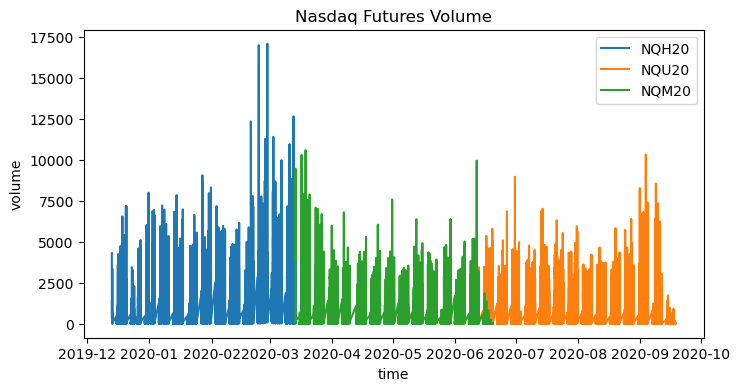

German Bunds - German Government Bonds: ['RXM25.csv', 'RXU25.csv', 'RXZ25.csv']


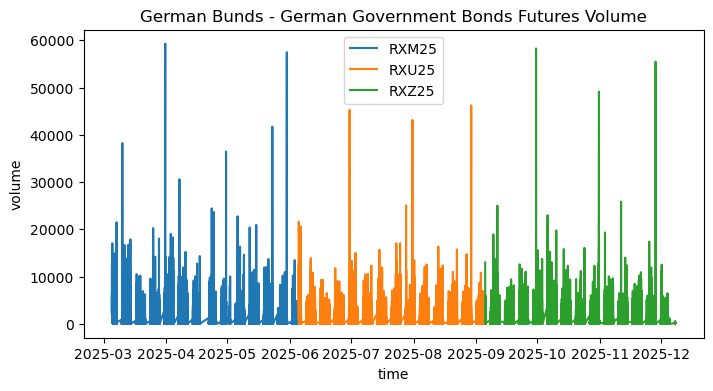

EuroStoxx: ['VGM22.csv', 'VGH22.csv']


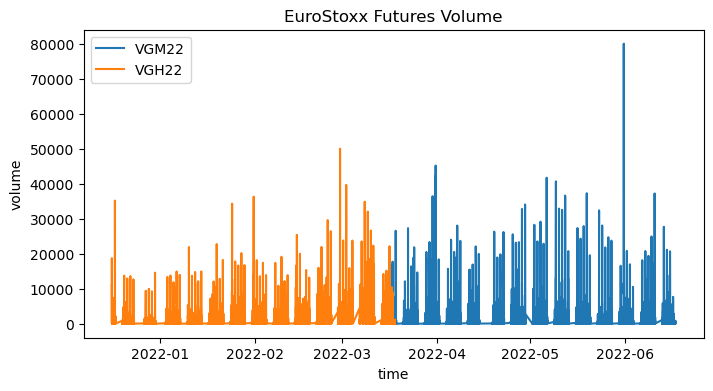

Gold: ['GCG24.csv', 'GCM24.csv', 'GCQ24.csv', 'GCJ24.csv']


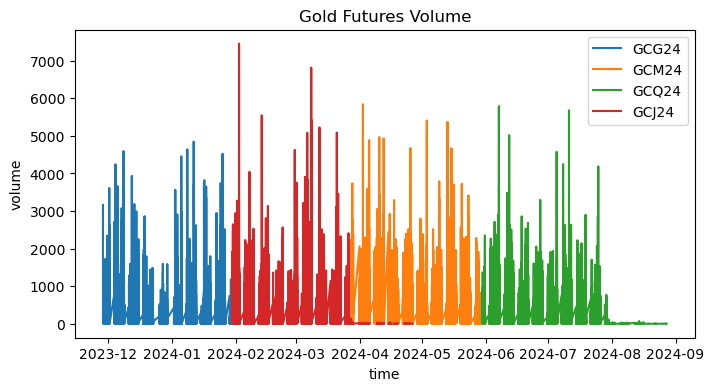

HeatingOil: ['HOM22.csv', 'HOK22.csv', 'HON22.csv', 'HOH22.csv', 'HOJ22.csv', 'HOF22.csv', 'HOG22.csv']


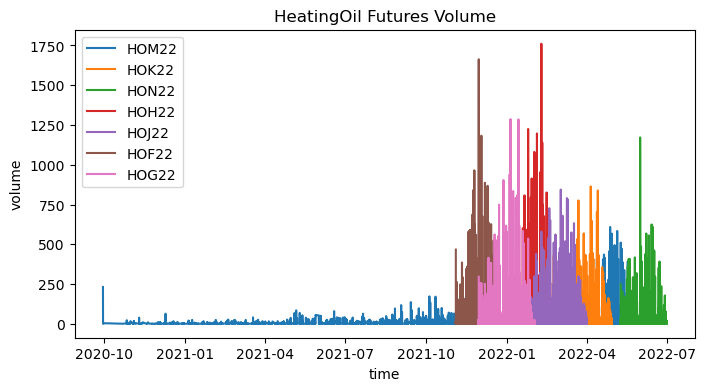

JPY - Japanese Yen: ['JYU24.csv', 'JYZ24.csv']


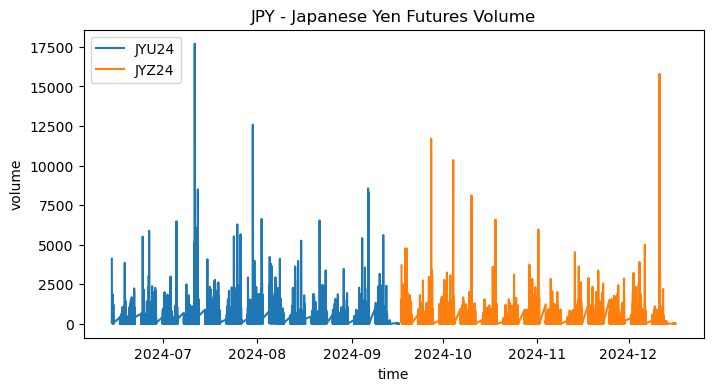

GBP - British Pound: ['BPM20.csv', 'BPU20.csv']


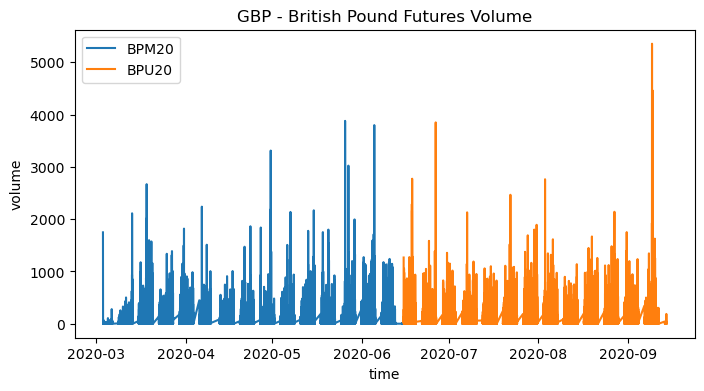

In [2]:
def plot_volume(raw_data_path:Path):
    markets=[p.name for p in raw_data_path.iterdir() if p.is_dir()]
    
    for market in markets:
        market_path=raw_data_path/market
        files=[ p.name for p in market_path.glob("*.csv")
               if not p.name.startswith("AIAgent")]
        print(f'{market}: {files}')
        
        volume_df=[]
        for file in files:
            data=pd.read_csv(market_path/file,header=None)
            data.columns=['time','open','high','low','close','volume']
            data[['open','high','low','close','volume']]=data[['open','high','low','close','volume']].astype(float)
            data['time']=pd.to_datetime(data['time'])
            data.set_index('time',inplace=True)
            
            max_volume=data['volume'].max()
            start_time=data[data['volume']>max_volume*0.2].index[0]
            data=data.loc[start_time:]
            data=data['volume']
            data.name=file[:-4]
            volume_df.append(data)
            
        volume_df=pd.concat(volume_df,axis=1,join='outer')
        
        plt.figure(figsize=(8,4))
        for f in volume_df.columns:
            plt.plot(volume_df.index,volume_df[f],label=f)
        plt.xlabel('time')
        plt.ylabel('volume')
        plt.title(f'{market} Futures Volume')
        plt.legend()
        plt.show()
            
plot_volume(RAW_DATA_DIR)

### **Improved approach (daily aggregation)**

The problem is that 1-minute data is noisy. A more stable approach is to work at the daily level.

Also, from my prior experience, contract rollover decisions depend on days to maturity, not minute-level fluctuations. This suggest that daily aggregation is more appropriate.

In addition, the PDF mentions using a trading coverage ratio. In illiquid periods, there are many missing observations. Since futures trade 23 hours per day, we expect $23\times 60=1380$ observations per day. In illiquid periods, the actual number is much lower.

So, we take the following procedure:

- Resample volume to daily frequency

- count the number of observations per day

- compute trading coverage ratio
$$
\text{coverage}=\frac{\text{\# observations}}{1380}
$$

- compute maximum daily volume

- find the first date where daily volume exceeds 10% of the maximum

- keep data after this date as the liquid period

**Two filtering methods**

We compare two approaches:

1. **volume threshold (chosen method)**

- vertical balck line: first date where daily volume exceeds 10% of max daily volume

- keep data to the right of this line

- works robustly across all assets, including Heating Oil

2. **Coverage ratio (rejected)**

- horizontal black line: 90% coverage threshold (as suggested in the PDF)

- works for some assets, but fails for Euro, German bond, Heating Oil

- these assets never reach 90%, even during liquid periods

So, we use the volume-based method.

EuroStoxx: ['VGH22.csv', 'VGM22.csv']


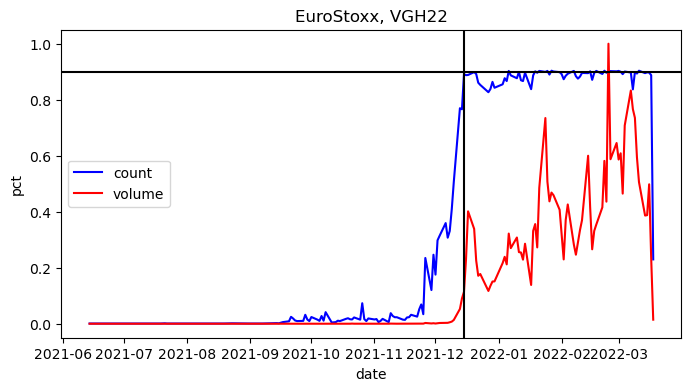

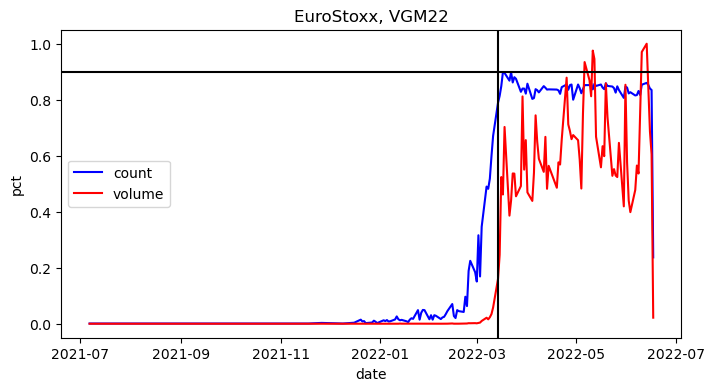

GBP - British Pound: ['BPM20.csv', 'BPU20.csv']


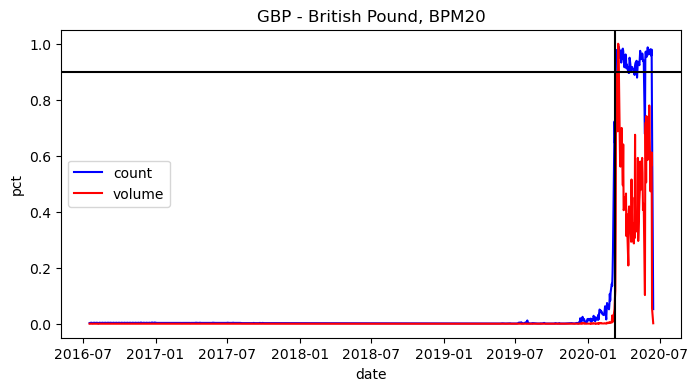

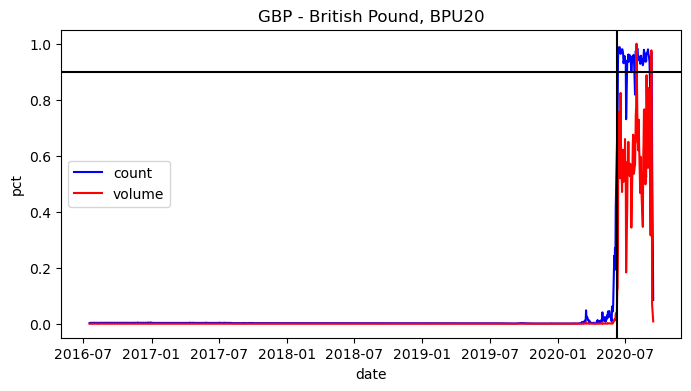

German Bunds - German Government Bonds: ['RXM25.csv', 'RXU25.csv', 'RXZ25.csv']


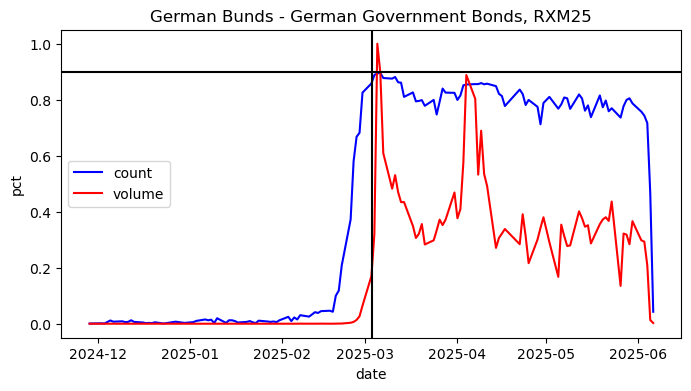

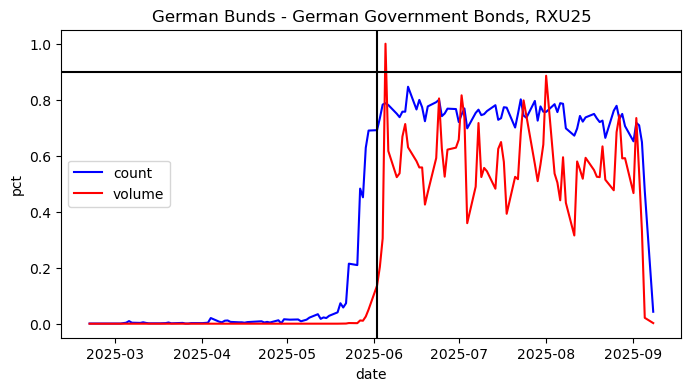

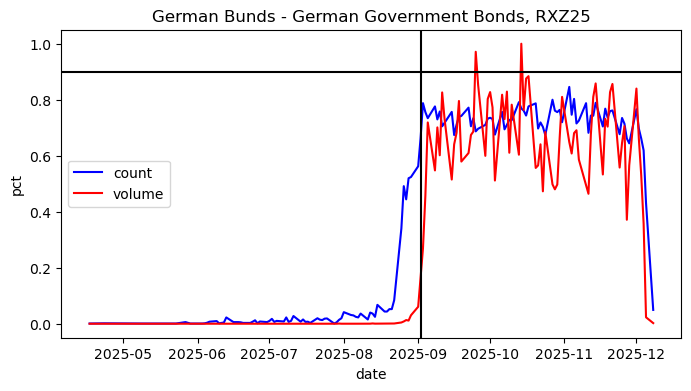

Gold: ['GCG24.csv', 'GCJ24.csv', 'GCM24.csv', 'GCQ24.csv']


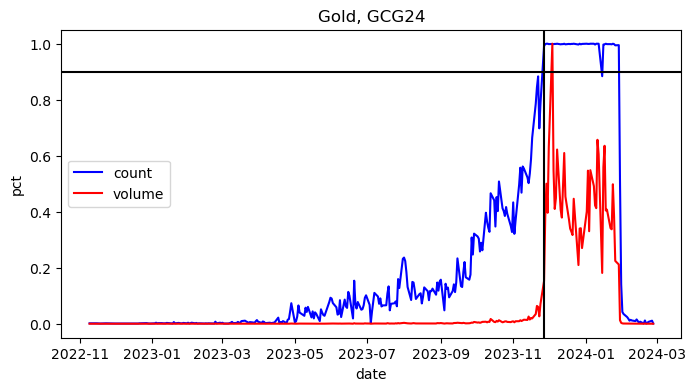

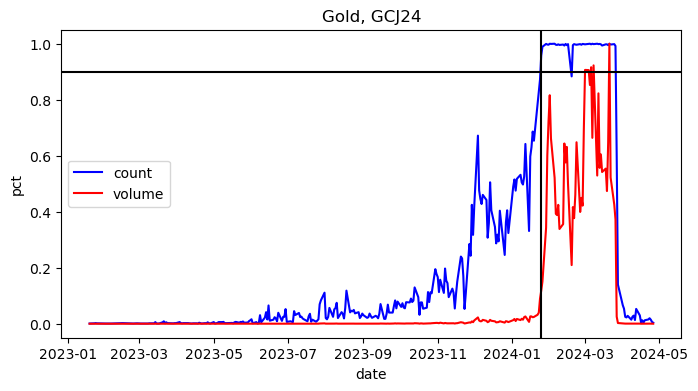

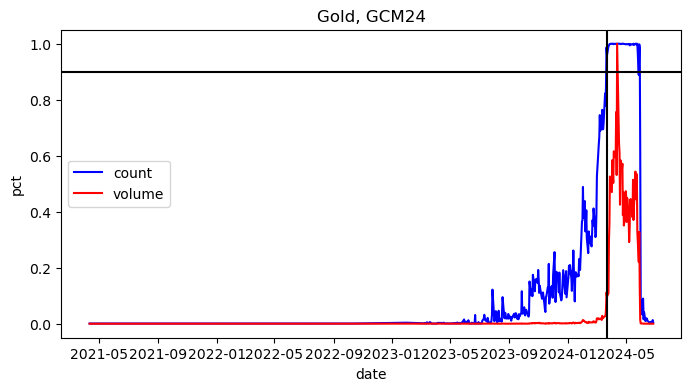

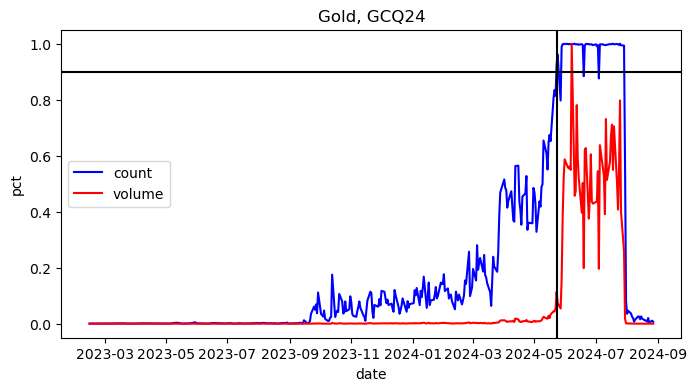

HeatingOil: ['HOF22.csv', 'HOG22.csv', 'HOH22.csv', 'HOJ22.csv', 'HOK22.csv', 'HOM22.csv', 'HON22.csv']


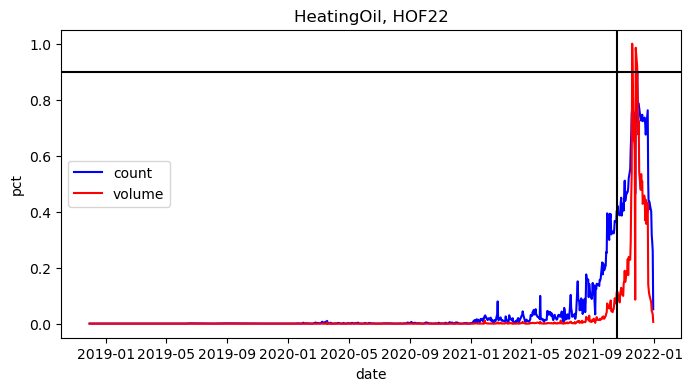

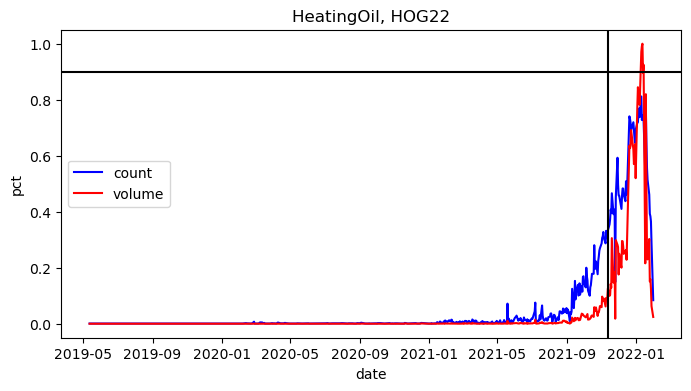

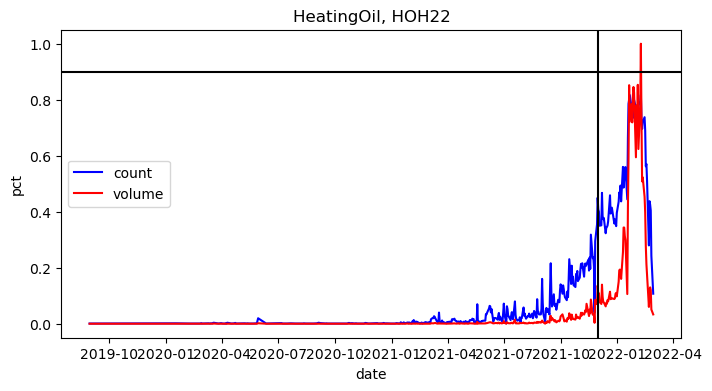

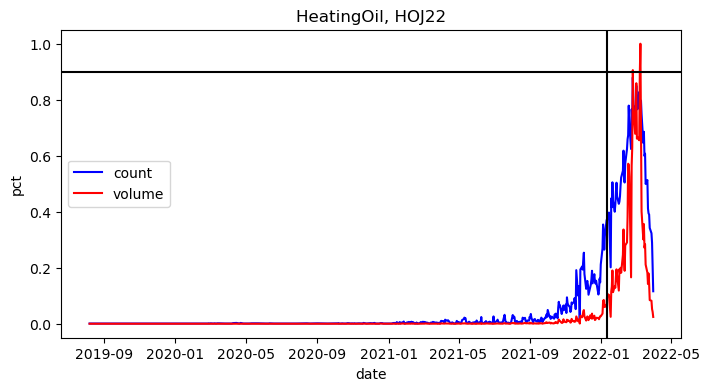

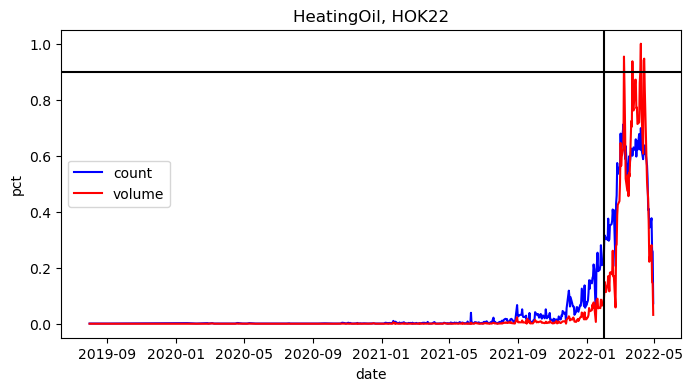

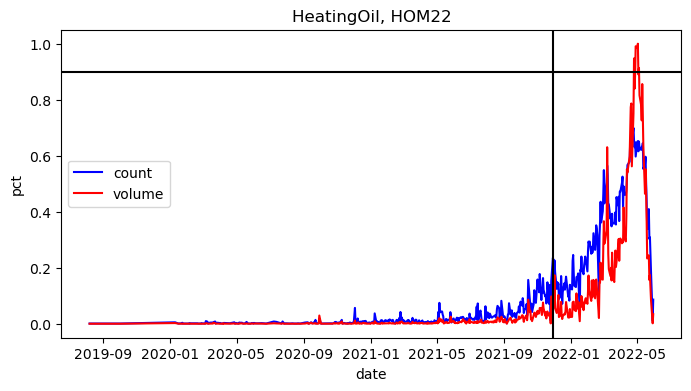

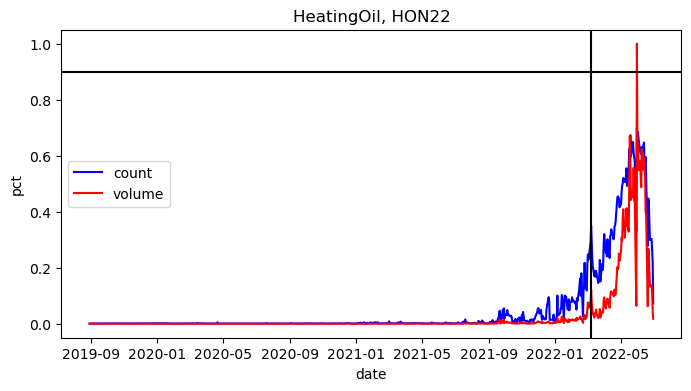

JPY - Japanese Yen: ['JYU24.csv', 'JYZ24.csv']


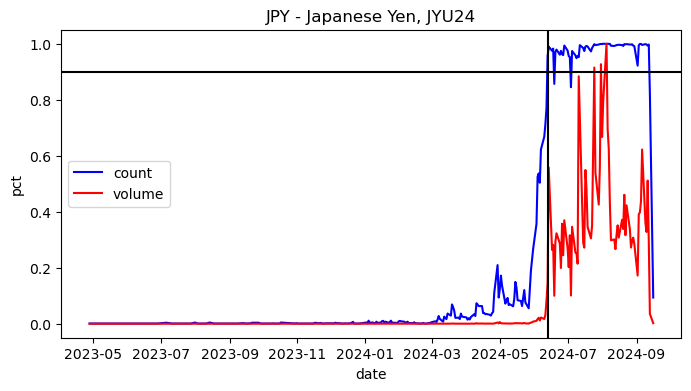

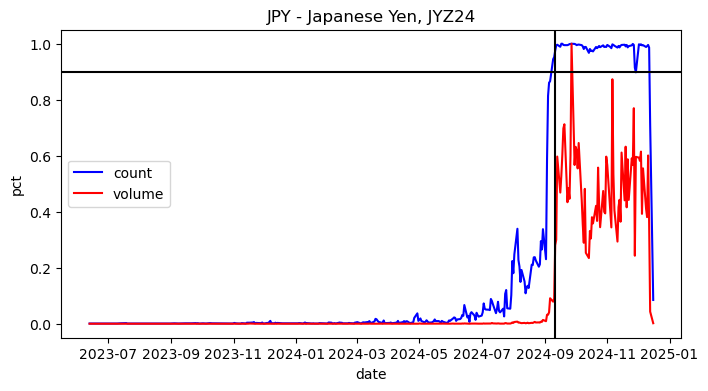

Nasdaq: ['NQH20.csv', 'NQM20.csv', 'NQU20.csv']


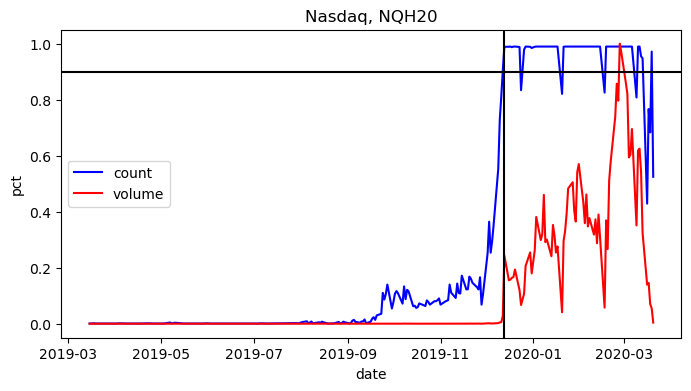

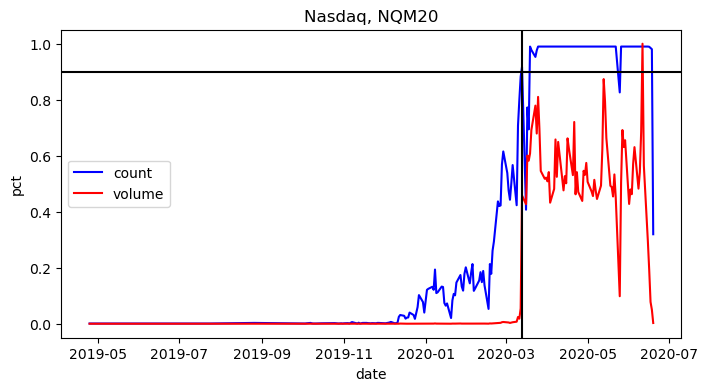

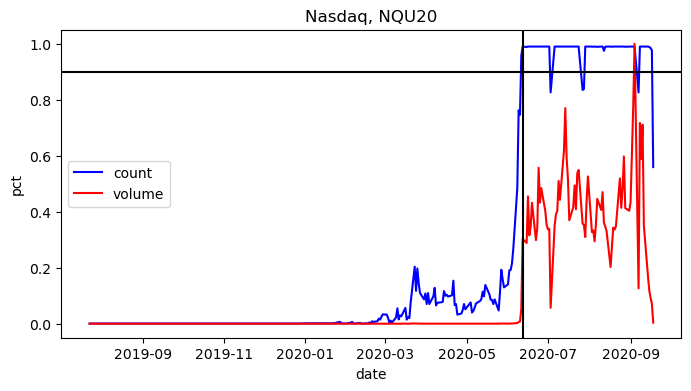

In [3]:
raw_data_path=RAW_DATA_DIR
markets=sorted([p.name for p in raw_data_path.iterdir() if p.is_dir()])

for market in markets:
    market_path=RAW_DATA_DIR/market
    files=sorted([p.name for p in market_path.glob("*.csv")
                  if not p.name.startswith("AIAgent")])
    print(f'{market}: {files}')
    hour_adjust=6
    
    for file in files:
        data=pd.read_csv(RAW_DATA_DIR/market/file)
        data.columns=['time','open','high','low','close','volume']
        data[['open','high','low','close','volume']]=data[['open','high','low','close','volume']].astype(float)
        data['time']=pd.to_datetime(data['time'])
        data['time']=data['time']+pd.Timedelta(hours=hour_adjust)
        data['date']=data['time'].dt.date
        data.set_index('time',inplace=True)

        # max_volume=data['volume'].max()
        # start_time=data[data['volume']>max_volume*0.2].index[0]
        
        count_series=data.groupby('date')['volume'].count()/float(23*60)
        max_series=data.groupby('date')['volume'].sum()
        max_series=max_series/max_series.max()
        start_date=max_series[max_series>0.1].index[0]
        start_time=data.loc[start_date:].index[0]

        plt.figure(figsize=(8,4))
        plt.plot(count_series.index,count_series.values,color='blue',label='count')
        plt.plot(max_series.index,max_series.values,color='red',label='volume')
        plt.axvline(start_time,color='black')
        plt.axhline(0.9,color='black')
        plt.xlabel('date')
        plt.ylabel('pct')
        plt.title(f'{market}, {file[:-4]}')
        plt.legend()
        plt.show()   

## **Step 2: Construct continuous contract**

The second task is to combine contracts into a continous sereis, i.e., determinte when to roll to the next contract.

We continue using daily data to avoid noisy switching at the minute level.

The method is straightforward:

- After filtering illiquid periods,

- for each day, select the contract with the highest volume

- this defines the front contract

The result is very clean: no back-and-forth switching. The plot shows a clear staircase pattern, which is exactly what we expect.

So we adopt this method.

**Note:** This approach may appear forward-looking: we identify the contract with the highest volume over the entire trading day, but use that information at the beginning of the day to decide which contract to trade.

However, our goal here is not to dynamically select the most liquid contract in real time. Instead, we aim to clearly segment front-contract periods and avoid frequent back-and-forth switching.

In practice, many firms use days-to-expiration rules to determine when to roll to the next contract. Once they roll, they typically do not switch back.

Our method produces a clean staircase-stype switching pattern, which is consistent with real-world behavior.

EuroStoxx: ['VGH22.csv', 'VGM22.csv']


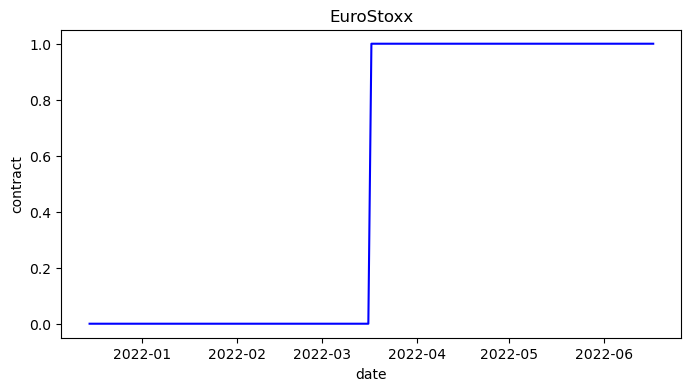

GBP - British Pound: ['BPM20.csv', 'BPU20.csv']


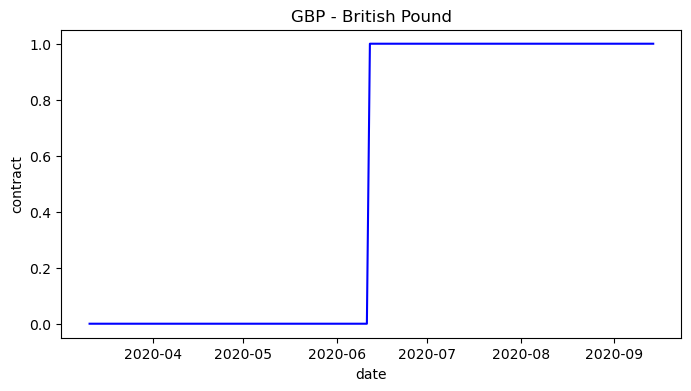

German Bunds - German Government Bonds: ['RXM25.csv', 'RXU25.csv', 'RXZ25.csv']


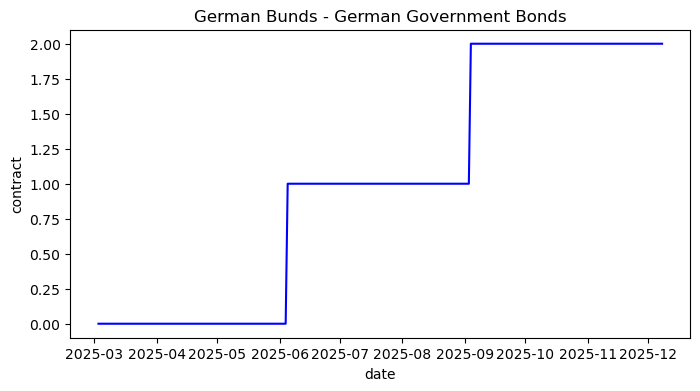

Gold: ['GCG24.csv', 'GCJ24.csv', 'GCM24.csv', 'GCQ24.csv']


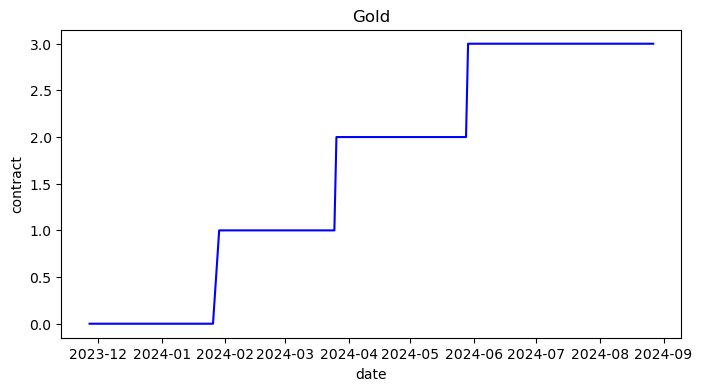

HeatingOil: ['HOF22.csv', 'HOG22.csv', 'HOH22.csv', 'HOJ22.csv', 'HOK22.csv', 'HOM22.csv', 'HON22.csv']


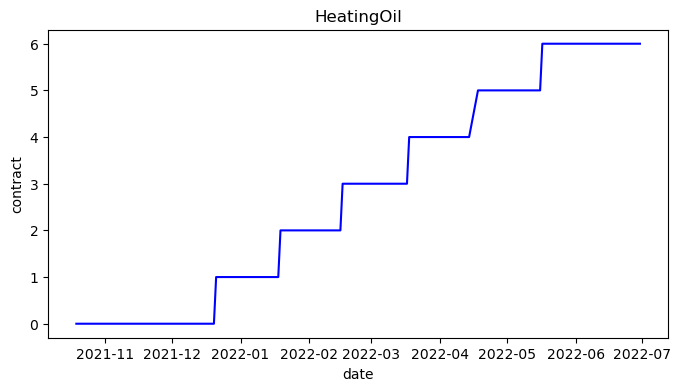

JPY - Japanese Yen: ['JYU24.csv', 'JYZ24.csv']


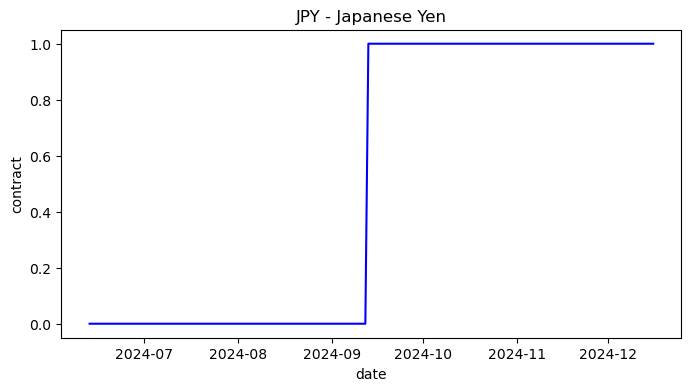

Nasdaq: ['NQH20.csv', 'NQM20.csv', 'NQU20.csv']


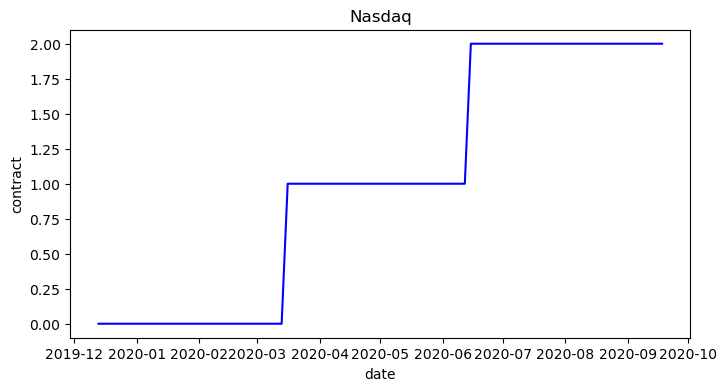

In [4]:
raw_data_path=RAW_DATA_DIR
markets=sorted([p.name for p in raw_data_path.iterdir() if p.is_dir()])

for market in markets:
    market_path=RAW_DATA_DIR/market
    files=sorted([p.name for p in market_path.glob("*.csv")
                  if not p.name.startswith("AIAgent")])
    print(f'{market}: {files}')
    hour_adjust=6
    
    volume_series_list=[]
    for file in files:
        data=pd.read_csv(RAW_DATA_DIR/market/file)
        data.columns=['time','open','high','low','close','volume']
        data[['open','high','low','close','volume']]=data[['open','high','low','close','volume']].astype(float)
        data['time']=pd.to_datetime(data['time'])
        data['time']=data['time']+pd.Timedelta(hours=hour_adjust)
        data['date']=data['time'].dt.date
        data.set_index('time',inplace=True)
        
        max_series=data.groupby('date')['volume'].sum()
        max_series=max_series/max_series.max()
        start_date=max_series[max_series>0.1].index[0]
        data=data.loc[start_date:]
        
        volume_series=data.groupby('date')['volume'].sum().dropna()
        volume_series.name=file[:-4]
        volume_series_list.append(volume_series)
        
    volume_df=pd.concat(volume_series_list,axis=1,join='outer')
    volume_df['contract']=np.nanargmax(volume_df.values,axis=1)
        

    plt.figure(figsize=(8,4))
    plt.plot(volume_df.index,volume_df['contract'].values,color='blue')
    plt.xlabel('date')
    plt.ylabel('contract')
    plt.title(f'{market}')
    plt.show()     

## **Final Output**

The cleaned futures data is stored in DATA_DIR/'futures'/'minute_1'.

Each file contains 8 columns:
$$
[\text{time, open, high, low, close, volume, date, contract}]
$$
where contract indicates which contract the data comes from.

Notes:

- We don't remove the illiquid tail of the final contract, since no alternative contract exists

- Data is aligned with AI agent timestamps; excess data is trimmed if necessary

However, I found a data issue:

- JPY: futures end on 2024-12-16, agent data ends on 2024-12-30 (14 days earlier)

- GBP: futures end on 2020-09-14, agent data ends on 2020-10-01 (17 days earlier)

- HeatingOil: futures end on 2020-06-30, agent data ends on 2020-07-01 (1 day earlier)

This inconsistency needs to be handled.

We will handle this problem when cleaning agent data, the method is to find the earlier one from futures' ending date and agent's ending date, and use that date to truncate the data.

In [5]:
raw_data_path=RAW_DATA_DIR
markets=sorted([p.name for p in raw_data_path.iterdir() if p.is_dir()])

market_dict={}
fields=['open', 'high', 'low', 'close', 'volume']


for market in markets:
    print(f'========== {market} ==========')
    market_path=RAW_DATA_DIR/market
    files=sorted([p.name for p in market_path.glob("*.csv")
                  if not p.name.startswith("AIAgent")])
    ai_file=[p.name for p in market_path.glob("*.csv")
             if p.name.startswith("AIAgent")][0]
    hour_adjust=6
    
    volume_series_list=[]
    data_dict={c: [] for c in fields}
    contract_names=[f[:-4] for f in files]
    
    for file in files:
        data=pd.read_csv(RAW_DATA_DIR/market/file,header=None)
        data=data.dropna() # delete rows with missing value
        data.columns=['time','open','high','low','close','volume']
        data=data.sort_values('time')
        data[['open','high','low','close','volume']]=data[['open','high','low','close','volume']].astype(float)
        data['time']=pd.to_datetime(data['time'])+pd.Timedelta(hours=hour_adjust) # change from calendar days to trading days
        data['date']=pd.to_datetime(data['time'].dt.date)
        data.set_index('time',inplace=True)
        
        # delete low volume period (beginning period)
        daily_volume=data.groupby('date')['volume'].sum()
        daily_volume_norm=daily_volume/daily_volume.max()
        valid_dates=daily_volume_norm[daily_volume_norm>0.1]
        if len(valid_dates)==0:
            print(f'Warning: {market}, {file}, no valid dates')
            continue
        start_date=pd.Timestamp(valid_dates.index[0])
        data=data.loc[data.index>=start_date]
        
        for c in fields:
            series=data[c].copy()
            series.name=file[:-4]
            data_dict[c].append(series)
        
        daily_volume=data.groupby('date')['volume'].sum()
        daily_volume.name=file[:-4]
        volume_series_list.append(daily_volume)
        
    if len(volume_series_list)==0:
        print(f'Warning: {market}, daily volume series list is empty.')
        continue
    
    # decide the rolling
    volume_df=pd.concat(volume_series_list,axis=1,join='outer').sort_index()
    volume_df=volume_df.reindex(contract_names,axis=1)
    volume_df=volume_df.dropna(how='all')
    volume_df['contract']=np.nanargmax(volume_df.values,axis=1)
    volume_df.reset_index(inplace=True)
    

    for c in fields:
        df=pd.concat(data_dict[c],axis=1,join='outer')
        df=df.reset_index()
        df['date']=pd.to_datetime(df['time'].dt.date)
        df=df.merge(volume_df[['date','contract']],on='date',how='inner')
        df=df.set_index('time')
        
        values = df[contract_names].to_numpy()
        row_idx = np.arange(len(df))
        col_idx = df['contract'].to_numpy()
        df[c] = values[row_idx, col_idx]
        data_dict[c] = df[c]
        
    combined_df=pd.DataFrame.from_dict(data_dict)
    combined_df.reset_index(inplace=True)
    combined_df['date']=pd.to_datetime(combined_df['time'].dt.date)
    combined_df=combined_df.merge(volume_df[['date','contract']],on='date',how='inner')
    
    market_dict[market]=combined_df
    
    ai_data=pd.read_csv(RAW_DATA_DIR/market/ai_file,header=None)
    ai_data.columns=['date','hour','minute','price','position']
    ai_data['date']=pd.to_datetime(ai_data['date'], unit='D', origin='1899-12-30')
    ai_data['time'] = (ai_data['date']
                       + pd.to_timedelta(ai_data['hour'], unit='h') 
                       + pd.to_timedelta(ai_data['minute'], unit='m'))
    ai_data['time']=ai_data['time']+pd.Timedelta(hours=hour_adjust)
    ai_data['date']=pd.to_datetime(ai_data['time'].dt.date)
    ai_data['hour']=(ai_data['time'].dt.hour).astype(int)
    ai_data['minute']=(ai_data['time'].dt.minute).astype(int)
    ai_data=ai_data.sort_values('time')
    
    start_days=(pd.Timestamp(combined_df['date'].iloc[0])-ai_data['date'].iloc[0]).days
    end_days=(pd.Timestamp(combined_df['date'].iloc[-1])-ai_data['date'].iloc[-1]).days
    
    if start_days>0:
        print(f'futures data starts {start_days} days later than agent data')
        print(f'futuers data start date: {combined_df['date'].iloc[0]}')
        print(f'agent data start date: {ai_data['date'].iloc[0]}')
    if end_days<0:
        print(f'futures data ends {-end_days} days earlier than agent data')
        print(f'futuers data end date: {combined_df['date'].iloc[-1]}')
        print(f'agent data end date: {ai_data['date'].iloc[-1]}')    
    
market_dict[market].head()

========== EuroStoxx ==========
========== GBP - British Pound ==========
futures data ends 17 days earlier than agent data
futuers data end date: 2020-09-14 00:00:00
agent data end date: 2020-10-01 00:00:00
========== German Bunds - German Government Bonds ==========
========== Gold ==========
========== HeatingOil ==========
futures data ends 1 days earlier than agent data
futuers data end date: 2022-06-30 00:00:00
agent data end date: 2022-07-01 00:00:00
========== JPY - Japanese Yen ==========
futures data ends 14 days earlier than agent data
futuers data end date: 2024-12-16 00:00:00
agent data end date: 2024-12-30 00:00:00
========== Nasdaq ==========


,time,open,high,low,close,volume,date,contract
0,2019-12-13 00:00:00,8508.00,8521.50,8508.00,8517.50,297.0,2019-12-13,0
1,2019-12-13 00:01:00,8517.50,8518.50,8516.25,8518.00,116.0,2019-12-13,0
2,2019-12-13 00:02:00,8518.25,8518.25,8515.75,8516.75,102.0,2019-12-13,0
3,2019-12-13 00:03:00,8516.75,8519.25,8516.75,8517.75,65.0,2019-12-13,0
4,2019-12-13 00:04:00,8518.75,8518.75,8517.50,8518.00,45.0,2019-12-13,0


## **Plot cleaned continous "front contract"**

The cleaned futures data is illusrated in the plots below:

- the volume represents the continous contract volume

- different background colors indicate which underlying contract the data comes from

- two vertical black lines indicate the start_time and end_time of agent data

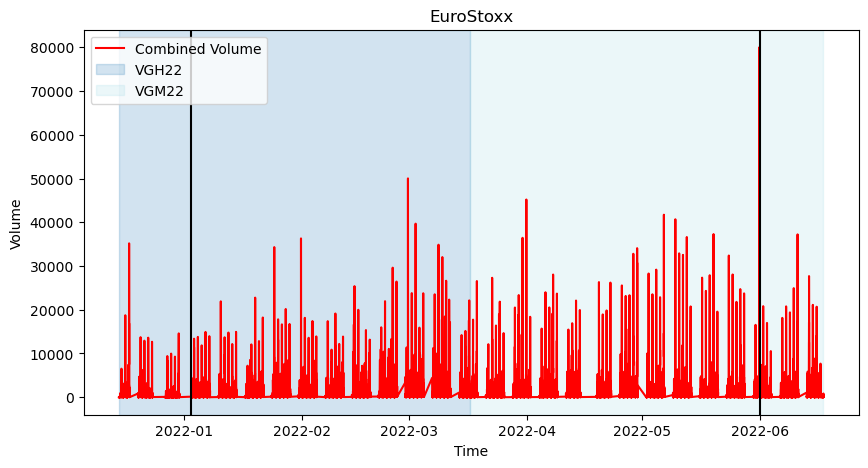

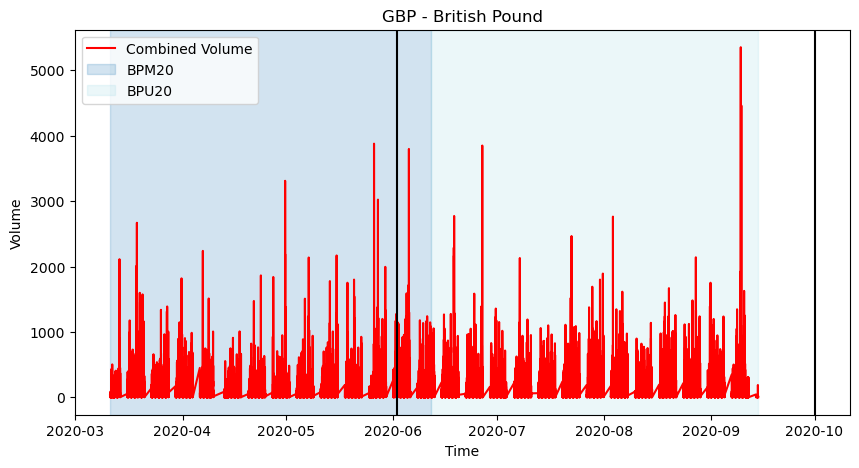

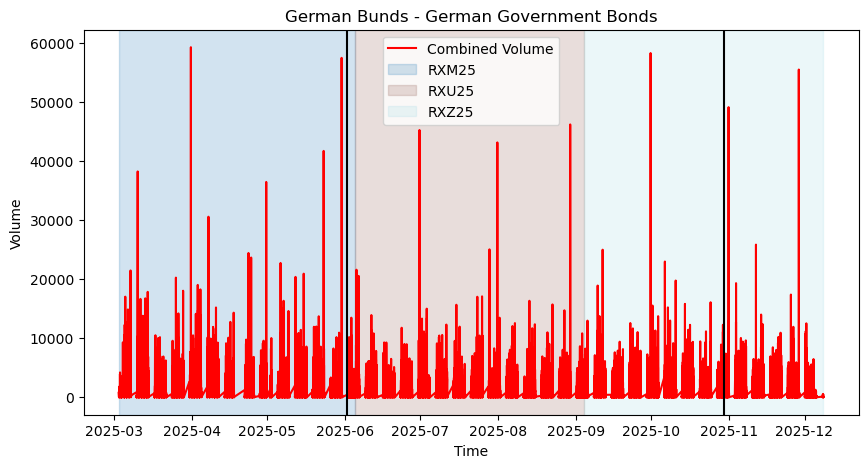

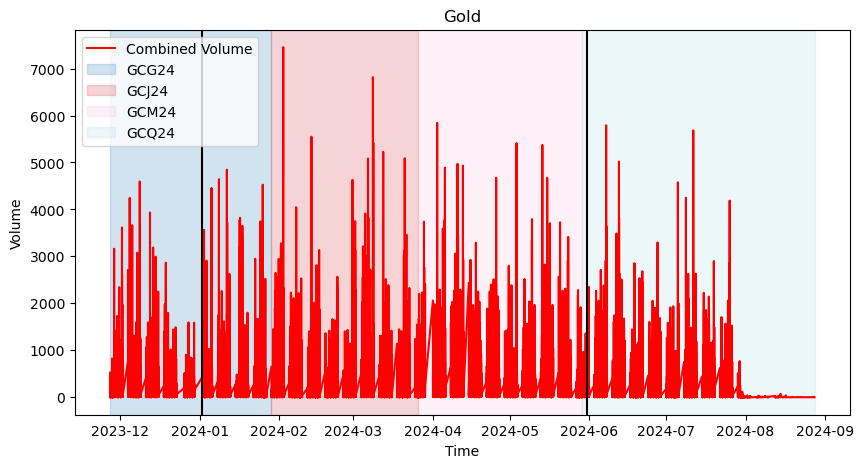

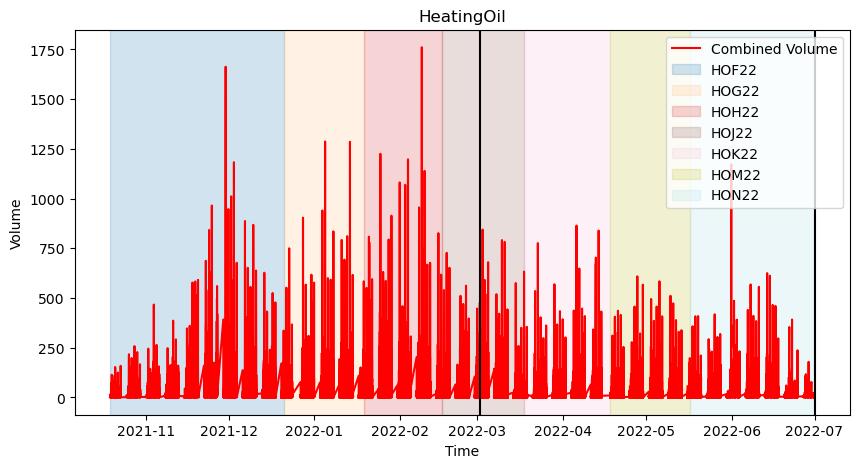

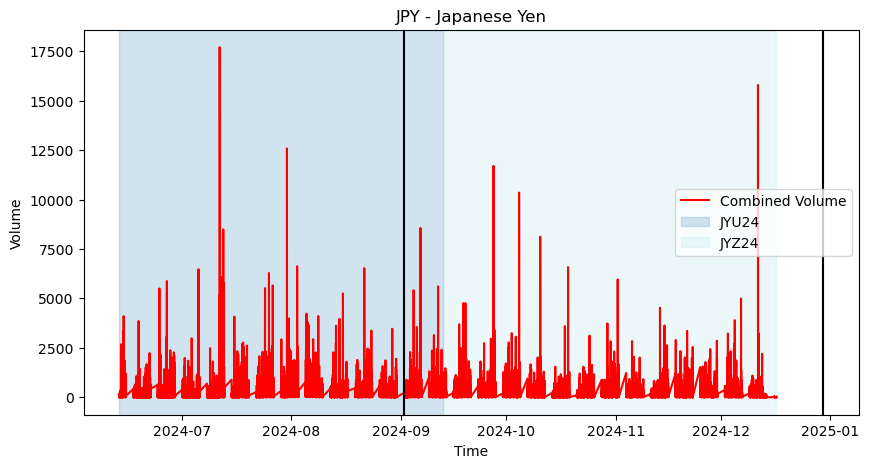

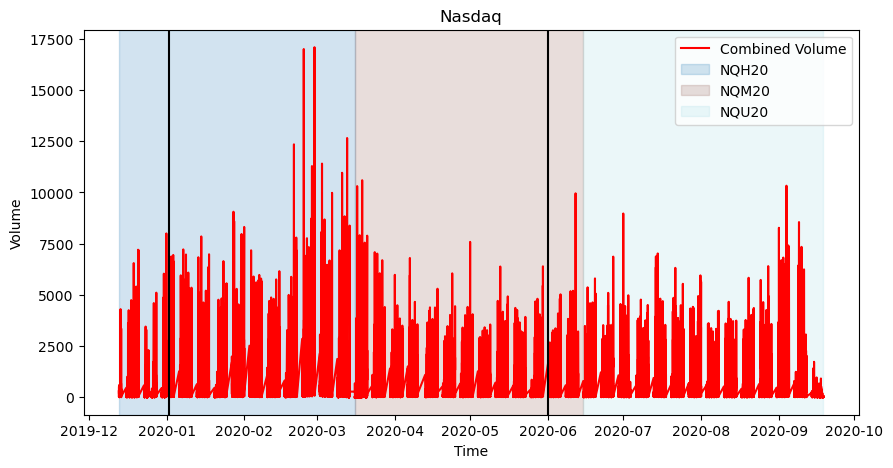

In [6]:
for market,df in market_dict.items():
    
    market_path=RAW_DATA_DIR/market
    files=sorted([p.name for p in market_path.glob("*.csv")
                  if not p.name.startswith("AIAgent")])
    ai_file=[p.name for p in market_path.glob("*.csv")
            if p.name.startswith("AIAgent")][0]
    contract_list=[f[:-4] for f in files]
    
    ai_data=pd.read_csv(RAW_DATA_DIR/market/ai_file,header=None)
    ai_data.columns=['date','hour','minute','price','position']
    ai_data['date']=pd.to_datetime(ai_data['date'], unit='D', origin='1899-12-30')
    ai_data['time'] = (ai_data['date']
                    + pd.to_timedelta(ai_data['hour'], unit='h') 
                    + pd.to_timedelta(ai_data['minute'], unit='m'))
    ai_data['time']=ai_data['time']+pd.Timedelta(hours=hour_adjust)
    ai_data['date']=pd.to_datetime(ai_data['time'].dt.date)
    start_date=ai_data['date'].iloc[0]
    end_date=ai_data['date'].iloc[-1]
    
    df_plot=df.copy()
    df_plot=df_plot.sort_values('time')
    df_plot.set_index('time',inplace=True)
    vol=df_plot['volume']  # volume series
    contract=df_plot['contract'] # contract series
    
    plt.figure(figsize=(10,5))
    plt.plot(vol.index,vol.values,color='red',label='Combined Volume')
    plt.axvline(start_date,color='black')
    plt.axvline(end_date,color='black')

    unique_contracts=np.unique(contract.dropna())
    colors=plt.cm.tab20(np.linspace(0,1,len(unique_contracts)))
    added_labels=set()
    
    for i,c_val in enumerate(unique_contracts):
        mask=(contract==c_val)
        start=None
        
        for t,m in zip(contract.index,mask):
            if m and start is None:
                start=t
            elif not m and start is not None:
                label=contract_list[int(c_val)]
                plt.axvspan(start,t,color=colors[i],alpha=0.2,label=label)
                added_labels.add(label)
                start=None
                
        # handle last segment
        if start is not None:
            label=contract_list[int(c_val)]
            plt.axvspan(start, contract.index[-1], color=colors[i], alpha=0.2,label=label)
            added_labels.add(label)

    plt.title(f"{market}")
    plt.xlabel("Time")
    plt.ylabel("Volume")
    plt.legend()
    plt.show()

# **Futures Data (agent-rule)**

Here the steps are a bit different from volume-rule cleaning. Here are more integral and the key idea is "matching". Matching the price of agent data to the futures data.

And in the former method, we first get 1-minute cleaned data and then resample to get 5-minute data. But here, due to matching, we directly get 5-minute cleaned data and continue to match to get 1-minute data.

In the results below, I print some information to help understand how to match and analysis some problems of matching. The biggest problem is that while agent data has all timestamps, futures data doesn't. So we encountered situations when we can't find timestamp in futures data, and these situations are marked as "time_not_found". Although there are many these situations, at timestamps when there is a trade happened, this problems are rare. So it's safe to ignore these problems in non-trading time and directly agent time as the close time in that interval and other prices are set to NaN. Also, when this happens, we don't know which contracts the agent was trading, so we use the continuous property of front contract as we mentioned in the last file. We can see that we can just fill with the former timestamp's contract. In the end, the plot also shows a clear start-case figure, which is very similar to the former plot.

The only thing we need to check is the difference between volume-rule based selection and agent-rule based selection. We will compare in the end.

In [7]:
def parse_contract_maturity(contract_name: str) -> pd.Timestamp:
    contract_name = str(contract_name).upper()
    m = re.search(r'([FGHJKMNQUVXZ])(\d{2})$', contract_name)
    if m is None:
        raise ValueError(f"Cannot parse maturity from contract name: {contract_name}")
    
    month = MONTH_CODE[m.group(1)]
    year = 2000 + int(m.group(2))
    return pd.Timestamp(year=year, month=month, day=1)


def build_contract_rank_map(futures_dict: dict) -> dict:
    contract_names = list(futures_dict.keys())
    maturity_pairs = [(name, parse_contract_maturity(name)) for name in contract_names]
    maturity_pairs = sorted(maturity_pairs, key=lambda x: x[1])
    
    rank_map = {name: i + 1 for i, (name, _) in enumerate(maturity_pairs)}
    return rank_map


def resample_one_contract_to_5min(
    df: pd.DataFrame, 
    time_col: str = "time",
) -> pd.DataFrame:
    """
    Resample one contract's 1-minute dataframe to 5-minute left-inclusive bars.
    """
    x = df.copy()
    x[time_col] = pd.to_datetime(x[time_col])
    x = x.sort_values(time_col).set_index(time_col)

    out = x.resample(
        "5min",
        label="right",
        closed="left"
    ).agg({
        "open": "first",
        "high": "max",
        "low": "min",
        "close": "last",
        "volume": "sum"
    })

    out = out.dropna(subset=["close"]).reset_index()
    return out


def resample_all_contracts(futures_dict: dict) -> dict:
    futures_5m_dict = {}
    for contract_name, df in futures_dict.items():
        futures_5m_dict[contract_name] = resample_one_contract_to_5min(df)
    return futures_5m_dict


def identify_agent_contracts(
    agent_df: pd.DataFrame,
    futures_dict: dict,
    price_tol: float = 0.0,
    time_col: str = "time",
    agent_price_col: str = "price"
) -> pd.DataFrame:

    agent = agent_df.copy()
    agent[time_col] = pd.to_datetime(agent[time_col])
    agent = agent.sort_values(time_col).reset_index(drop=True)

    # build rank map
    rank_map = build_contract_rank_map(futures_dict)

    # resample all contracts to 5min
    futures_5m_dict = resample_all_contracts(futures_dict)
    
    # same last timestamp of agent & futures data
    last_agent_timestamp = agent[time_col].max()
    last_futures_timestamp = max(
        df_5m[time_col].max()
        for df_5m in futures_5m_dict.values()
        if len(df_5m) > 0
    )
    last_timestamp = min(last_agent_timestamp, last_futures_timestamp)
    agent = agent[agent[time_col] <= last_timestamp].copy()

    # build quick lookup for each contract:
    lookup_dict = {}
    for contract_name, df_5m in futures_5m_dict.items():
        temp = df_5m.copy()
        temp = temp[temp[time_col] <= last_timestamp]
        temp = temp.set_index(time_col)[["close", "volume"]]
        lookup_dict[contract_name] = temp
        
    # to store result row by row
    matched_contracts_all = []
    matched_ranks_all = []
    matched_volumes_all = []
    match_status_all=[]

    # first iterate: agent
    for _, row in agent.iterrows():
        t = row[time_col]
        p = row[agent_price_col]

        matched_contracts = []
        matched_ranks = []
        matched_volumes = []
        time_found = False

        # second iterate: future contracts
        for contract_name, lookup_df in lookup_dict.items():
            if t not in lookup_df.index:
                continue
            
            time_found = True

            close_price = lookup_df.at[t, "close"]
            vol = lookup_df.at[t, "volume"]

            if price_tol == 0.0:
                is_match = (p == close_price)
            else:
                is_match = abs(p - close_price) <= price_tol

            if is_match:
                matched_contracts.append(contract_name)
                matched_ranks.append(rank_map[contract_name])
                matched_volumes.append(vol)
                
        if len(matched_contracts) > 0:
            match_status_all.append("done")
        elif not time_found:
            match_status_all.append("time_not_found")
        else:
            match_status_all.append("no_price")

        matched_contracts_all.append(matched_contracts)
        matched_ranks_all.append(matched_ranks)
        matched_volumes_all.append(matched_volumes)

    agent["matched_contracts"] = matched_contracts_all
    agent["matched_contract_ranks"] = matched_ranks_all
    agent["matched_contract_volumes"] = matched_volumes_all
    agent["match_status"] = match_status_all

    # choose one by largest volume if multiple contracts match
    chosen_contract = []
    chosen_rank = []
    chosen_volume = []

    for contracts, ranks, vols in zip(
        agent["matched_contracts"],
        agent["matched_contract_ranks"],
        agent["matched_contract_volumes"]
    ):
        if len(contracts) == 0:
            chosen_contract.append(np.nan)
            chosen_rank.append(np.nan)
            chosen_volume.append(np.nan)
        elif len(contracts) == 1:
            chosen_contract.append(contracts[0])
            chosen_rank.append(ranks[0])
            chosen_volume.append(vols[0])
        else:
            idx = int(np.argmax(vols))
            chosen_contract.append(contracts[idx])
            chosen_rank.append(ranks[idx])
            chosen_volume.append(vols[idx])

    agent["chosen_contract"] = chosen_contract
    agent["chosen_contract_rank"] = chosen_rank
    agent["chosen_contract_volume"] = chosen_volume

    return agent


def build_front_5min_from_agent(
    agent: pd.DataFrame,
    futures_dict: dict,
    time_col: str = "time",
    agent_price_col: str = "price"
) -> pd.DataFrame:

    futures_5m_dict = resample_all_contracts(futures_dict)

    lookup_5m = {}
    for contract, df in futures_5m_dict.items():
        temp = df.copy()
        temp[time_col] = pd.to_datetime(temp[time_col])
        temp = temp.set_index(time_col)
        lookup_5m[contract] = temp

    rows = []

    for _, row in agent.iterrows():
        t = row[time_col]
        p_agent = row[agent_price_col]
        contract = row["front_contract"]
        status = row["match_status"]

        out = {
            time_col: t,
            "contract": contract,
            "rank": row["front_rank"],
            "match_status": status,
        }

        if contract in lookup_5m and t in lookup_5m[contract].index:
            bar = lookup_5m[contract].loc[t]

            if status == "done":
                out.update({
                    "open": bar["open"],
                    "high": bar["high"],
                    "low": bar["low"],
                    "close": bar["close"],
                    "volume": bar["volume"],
                })
            else:
                out.update({
                    "open": np.nan,
                    "high": np.nan,
                    "low": np.nan,
                    "close": p_agent,
                    "volume": np.nan,
                })
        else:
            out.update({
                "open": np.nan,
                "high": np.nan,
                "low": np.nan,
                "close": p_agent,
                "volume": np.nan,
            })

        rows.append(out)

    return pd.DataFrame(rows)


def build_front_1min_from_agent(
    agent: pd.DataFrame,
    futures_dict: dict,
    time_col: str = "time",
    agent_price_col: str = "price"
) -> pd.DataFrame:

    lookup_1m = {}

    for contract, df in futures_dict.items():
        temp = df.copy()
        temp[time_col] = pd.to_datetime(temp[time_col])
        temp = temp.sort_values(time_col).set_index(time_col)
        lookup_1m[contract] = temp

    rows = []

    for _, row in agent.iterrows():
        t = row[time_col]
        p_agent = row[agent_price_col]
        contract = row["front_contract"]
        status = row["match_status"]

        interval_times = pd.date_range(
            start=t - pd.Timedelta(minutes=5),
            end=t - pd.Timedelta(minutes=1),
            freq="1min"
        )

        if status == "done" and contract in lookup_1m:
            contract_1m = lookup_1m[contract]
            bars = contract_1m.reindex(interval_times).reset_index()
            bars = bars.rename(columns={"index": time_col})

            bars["contract"] = contract
            bars["rank"] = row["front_rank"]
            bars["agent_time"] = t
            bars["match_status"] = status

        else:
            bars = pd.DataFrame({
                time_col: interval_times,
                "open": np.nan,
                "high": np.nan,
                "low": np.nan,
                "close": np.nan,
                "volume": np.nan,
                "contract": contract,
                "rank": row["front_rank"],
                "agent_time": t,
                "match_status": status,
            })

            # last 1-min bar close equals agent price
            bars.loc[bars[time_col] == t - pd.Timedelta(minutes=1), "close"] = p_agent

        rows.append(bars)

    return pd.concat(rows, ignore_index=True)


def build_prep_5min_from_agent(
    agent: pd.DataFrame,
    futures_dict: dict,
    time_col: str = "time",
) -> pd.DataFrame:
    if agent.empty:
        return pd.DataFrame(
            columns=[time_col, "open", "high", "low", "close", "volume", "contract", "rank"]
        )

    first_agent_timestamp, first_front_contract, first_front_rank, prep_start_date = (
        get_prep_window_info(agent, futures_dict, time_col=time_col)
    )

    contract_5m = resample_one_contract_to_5min(
        futures_dict[first_front_contract], time_col=time_col
    )
    prep = contract_5m[
        (contract_5m[time_col] < first_agent_timestamp)
        & (contract_5m[time_col].dt.normalize() >= prep_start_date)
    ].copy()
    prep["contract"] = first_front_contract
    prep["rank"] = first_front_rank

    return prep[[time_col, "open", "high", "low", "close", "volume", "contract", "rank"]]


def build_prep_1min_from_agent(
    agent: pd.DataFrame,
    futures_dict: dict,
    time_col: str = "time",
) -> pd.DataFrame:
    if agent.empty:
        return pd.DataFrame(
            columns=[time_col, "open", "high", "low", "close", "volume", "contract", "rank"]
        )

    first_agent_timestamp, first_front_contract, first_front_rank, prep_start_date = (
        get_prep_window_info(agent, futures_dict, time_col=time_col)
    )

    prep = futures_dict[first_front_contract].copy()
    prep[time_col] = pd.to_datetime(prep[time_col])
    prep = prep.sort_values(time_col)
    prep = prep[
        (prep[time_col] < first_agent_timestamp)
        & (prep[time_col].dt.normalize() >= prep_start_date)
    ].copy()
    prep["contract"] = first_front_contract
    prep["rank"] = first_front_rank

    return prep[[time_col, "open", "high", "low", "close", "volume", "contract", "rank"]]


def get_prep_window_info(
    agent: pd.DataFrame,
    futures_dict: dict,
    time_col: str = "time",
):
    agent_sorted = agent.sort_values(time_col)
    first_agent_timestamp = pd.to_datetime(agent_sorted[time_col]).min()
    first_front_contract = agent_sorted["front_contract"].iloc[0]
    first_front_rank = int(agent_sorted["front_rank"].iloc[0])

    contract_df = futures_dict[first_front_contract].copy()
    contract_df[time_col] = pd.to_datetime(contract_df[time_col])
    contract_df = contract_df.sort_values(time_col)
    contract_df["trade_date"] = contract_df[time_col].dt.normalize()

    daily_volume = contract_df.groupby("trade_date", as_index=False)["volume"].sum()
    volume_threshold = daily_volume["volume"].max() / 10.0
    liquid_days = daily_volume[daily_volume["volume"] >= volume_threshold]

    if liquid_days.empty:
        prep_start_date = contract_df["trade_date"].min()
    else:
        prep_start_date = liquid_days["trade_date"].iloc[0]

    return first_agent_timestamp, first_front_contract, first_front_rank, prep_start_date

======== EuroStoxx ========
match_status
time_not_found    3803
Name: count, dtype: int64
no mathing contract: 3803, pct=12.85
more mathing: 0, pct=0.00
match_status
time_not_found    3
Name: count, dtype: int64
no mathing contract (trading): 3, pct=1.42
more mathing (trading): 0, pct=0.00


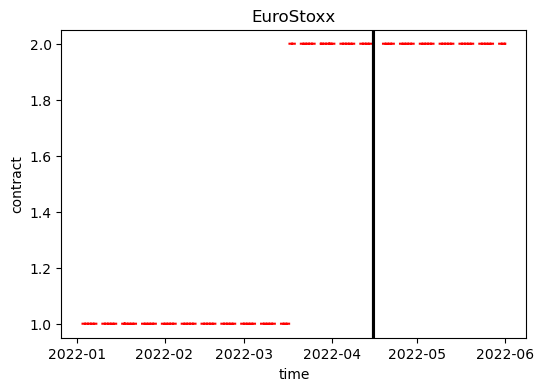

======== GBP - British Pound ========
match_status
time_not_found    367
no_price          317
Name: count, dtype: int64
no mathing contract: 684, pct=3.33
more mathing: 13, pct=0.06
match_status
no_price          8
time_not_found    2
Name: count, dtype: int64
no mathing contract (trading): 10, pct=2.23
more mathing (trading): 0, pct=0.00


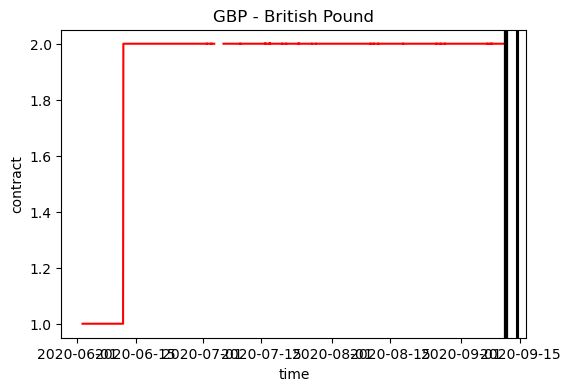

======== German Bunds - German Government Bonds ========
match_status
time_not_found    4580
no_price            28
Name: count, dtype: int64
no mathing contract: 4608, pct=15.46
more mathing: 0, pct=0.00
match_status
time_not_found    1
Name: count, dtype: int64
no mathing contract (trading): 1, pct=0.16
more mathing (trading): 0, pct=0.00


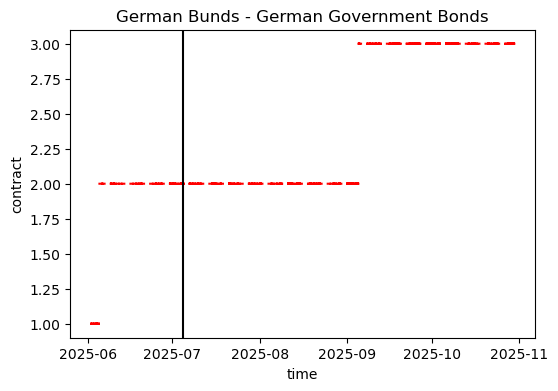

======== Gold ========
match_status
no_price          609
time_not_found    366
Name: count, dtype: int64
no mathing contract: 975, pct=3.25
more mathing: 0, pct=0.00
match_status
no_price          9
time_not_found    2
Name: count, dtype: int64
no mathing contract (trading): 11, pct=0.86
more mathing (trading): 0, pct=0.00


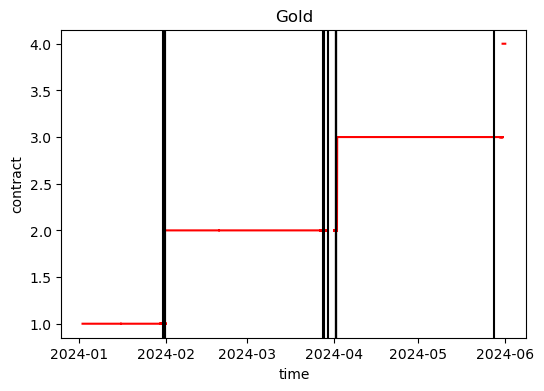

======== HeatingOil ========
match_status
time_not_found    3550
no_price          1871
Name: count, dtype: int64
no mathing contract: 5421, pct=22.67
more mathing: 0, pct=0.00
match_status
no_price          23
time_not_found    14
Name: count, dtype: int64
no mathing contract (trading): 37, pct=12.76
more mathing (trading): 0, pct=0.00


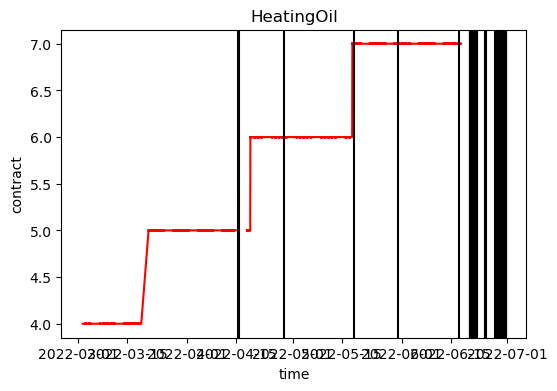

======== JPY - Japanese Yen ========
match_status
no_price          346
time_not_found    155
Name: count, dtype: int64
no mathing contract: 501, pct=2.41
more mathing: 0, pct=0.00
match_status
no_price          4
time_not_found    2
Name: count, dtype: int64
no mathing contract (trading): 6, pct=0.79
more mathing (trading): 0, pct=0.00


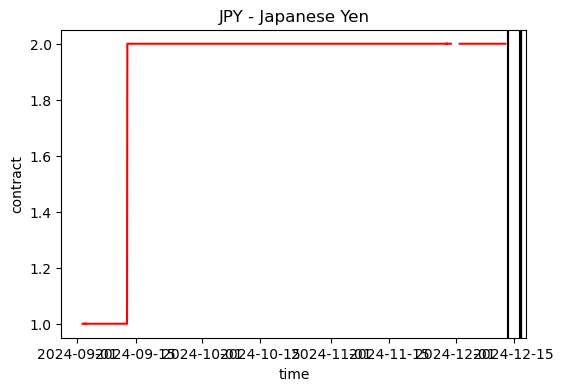

======== Nasdaq ========
match_status
time_not_found    747
no_price           56
Name: count, dtype: int64
no mathing contract: 803, pct=2.72
more mathing: 42, pct=0.14
match_status
time_not_found    4
Name: count, dtype: int64
no mathing contract (trading): 4, pct=0.18
more mathing (trading): 6, pct=0.28


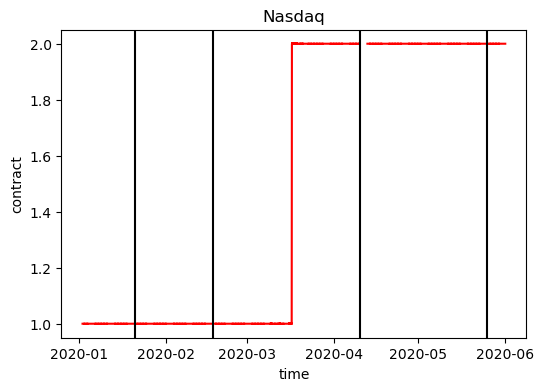

In [8]:
raw_data_path=RAW_DATA_DIR
markets=sorted([p.name for p in raw_data_path.iterdir() if p.is_dir()])

for market in markets:
    print(f'======== {market} ========')
    market_path=raw_data_path/market
        
    files=sorted([p.name for p in market_path.glob("*.csv")
                if not p.name.startswith("AIAgent")])
    ai_file=[p.name for p in market_path.glob("*.csv")
                if p.name.startswith("AIAgent")][0]

    # futures_data
    futures_dict=dict()
    for f in files:
        data=pd.read_csv(RAW_DATA_DIR/market/f,header=None)
        data=data.dropna() # delete rows with missing value, this doesn't change the results here
        data.columns=['time','open','high','low','close','volume']
        data['time']=pd.to_datetime(data['time'])+ pd.Timedelta(hours=6) # change to trading clock
        data = data[data["time"].dt.dayofweek < 5]                    # delete Saturdays and Sundays
        data['hour']=(data['time'].dt.hour).astype(int)
        data=data[data['hour']!=23]                                   # delete breaking time
        data=data[['time','open','high','low','close','volume']]
        
        futures_dict[f[:-4]]=data
    
    # agent_data
    agent_df=pd.read_csv(RAW_DATA_DIR/market/ai_file,header=None)
    agent_df.columns=['date','hour','minute','price','position']
    agent_df['date']=pd.to_datetime(agent_df['date'], unit='D', origin='1899-12-30')
    agent_df['time'] = (agent_df['date']
                        + pd.to_timedelta(agent_df['hour'], unit='h') 
                        + pd.to_timedelta(agent_df['minute'], unit='m'))
    agent_df['time']=pd.to_datetime(agent_df['time']) + pd.Timedelta(hours=6) # change to trading clock
    agent_df = agent_df[agent_df["time"].dt.dayofweek < 5]                    # delete Saturdays and Sundays
    agent_df['hour']=(agent_df['time'].dt.hour).astype(int)
    # agent_df['trade']=agent_df['position'].diff()
    # agent_df=agent_df[(agent_df['hour']!=17)&(agent_df['trade']!=0)]
    agent_df = agent_df[
        ~(
            ((agent_df["time"].dt.hour == 23) & (agent_df["time"].dt.minute >= 5))
            | ((agent_df["time"].dt.hour == 0) & (agent_df["time"].dt.minute == 0))
        )
    ] # delete breaking time
    
    # result
    agent=identify_agent_contracts(agent_df,futures_dict)
    
    # analysis
    n_no_matching=agent[agent['chosen_contract_rank'].isna()]
    print(n_no_matching["match_status"].value_counts(dropna=False))
    print(f'no mathing contract: {len(n_no_matching)}, pct={len(n_no_matching)/len(agent)*100:.2f}')
    more_matching=agent[agent['matched_contracts'].apply(len) > 1]
    print(f'more mathing: {len(more_matching)}, pct={len(more_matching)/len(agent)*100:.2f}')
    
    # analysis (trading)
    agent['trade']=agent['position'].diff().fillna(0)
    agent_trading=agent[agent['trade']!=0].copy()
    n_no_matching=agent_trading[agent_trading['chosen_contract_rank'].isna()]
    print(n_no_matching["match_status"].value_counts(dropna=False))
    print(f'no mathing contract (trading): {len(n_no_matching)}, pct={len(n_no_matching)/len(agent_trading)*100:.2f}')
    more_matching=agent_trading[agent_trading['matched_contracts'].apply(len) > 1]
    print(f'more mathing (trading): {len(more_matching)}, pct={len(more_matching)/len(agent_trading)*100:.2f}')
    
    no_matching_time=agent_trading[agent_trading['chosen_contract_rank'].isna()]['time'].values.tolist()
    
    plt.figure(figsize=(6,4))
    plt.plot(agent['time'],agent['chosen_contract_rank'],color='red')
    for t in pd.to_datetime(agent_trading[agent_trading['chosen_contract_rank'].isna()]['time'].values):
        plt.axvline(t,color='black')
    plt.xlabel('time')
    plt.ylabel('contract')
    plt.title(f'{market}')
    plt.show()

# **AI Agent Data**

Minimal preprocessing is applied:

- rename columns

- convert calendar time to traing time (+6 hours shift)

- remove Weekends (Although we have proved that there are no weekends, we make sure here)

- cooperate with futures data to find the final ending date

Each file contains 6 columns:
$$
[\text{date, hour, minute, price, position,time}]
$$

In [9]:
# run "clean_agent_data()" first
# here we display the cleaned agent data.

market='Nasdaq'
data=pd.read_parquet(DATA_DIR/'agent'/f'{market}.parquet')
data.head()

,date,hour,minute,price,position,time
0,2020-01-02,6,0,8787.75,0,2020-01-02 06:00:00
1,2020-01-02,6,5,8787.75,0,2020-01-02 06:05:00
2,2020-01-02,6,10,8786.00,0,2020-01-02 06:10:00
3,2020-01-02,6,15,8785.50,0,2020-01-02 06:15:00
4,2020-01-02,6,20,8785.25,0,2020-01-02 06:20:00


# **Resample Futures Data**

Futures data is 1-minuute, while agent data is 5-minute, so we resample.

We implement a generic function for x-minute aggregation (x divides 60).

For each interval:

- open: first price

- close: last price

- high: max

- low: min

- volume: sum

- n_rows: trading coverage ratio

We use 5-minute resampled data as an example. The PDF suggests a left-inclusive convention, where a timestamp such as 14:05 represents the interval [14:05,14:10). But we have already argued that this is only correct if we only study futures data. If we want to compare with agent data, we need to use right-inclusive interval. For example, to get the OHLCV at 14:05, when need to calculate based on the OHLCV of [14:00,14:05).

In [10]:
market='Nasdaq'
data=pd.read_parquet(DATA_DIR/'futures'/'minute_1'/f'{market}.parquet')
data.set_index('time',inplace=True)

data['ones']=1
data_5min=data.resample('5min',label='right',closed='left').agg({
    'open':'first',
    'high':'max',
    'low':'min',
    'close':'last',
    'volume':'sum',
    'date':'first',
    'contract':'first',
    'ones': 'sum'
}).rename(columns={'ones': 'n_rows'}).dropna(subset=['open', 'high', 'low', 'close']).reset_index()

data_5min['contract']=data_5min['contract'].astype(int)
data_5min['n_rows']=data_5min['n_rows']/float(5)
data_5min.head()

,time,open,high,low,close,volume,date,contract,n_rows
0,2019-12-13 00:05:00,8508.00,8521.50,8508.00,8518.00,625.0,2019-12-13,0,1.0
1,2019-12-13 00:10:00,8517.50,8524.25,8517.50,8522.75,680.0,2019-12-13,0,1.0
2,2019-12-13 00:15:00,8522.50,8523.25,8521.00,8521.50,163.0,2019-12-13,0,1.0
3,2019-12-13 00:20:00,8521.25,8521.25,8517.50,8518.50,322.0,2019-12-13,0,1.0
4,2019-12-13 00:25:00,8519.00,8521.50,8517.75,8518.25,181.0,2019-12-13,0,1.0


# **Data Comparasion: volume-rule vs agent-rule**

We compare the contract choosen by these two methods.

Apart from HeaingOil, other assets show very close similarity. The tiny difference is that volume-rule will change the front contract a bit earlier. 

But HeatingOil shows a huge difference, why? After searching for the reason, we find that this is because trading period doesn't begin in the first contract (this can be seen from the plot part of the volume-rule). So we can't decide which contract the early part comes from. In this situation, we use data from volume-rule part as our data. This requires us to fix the code.

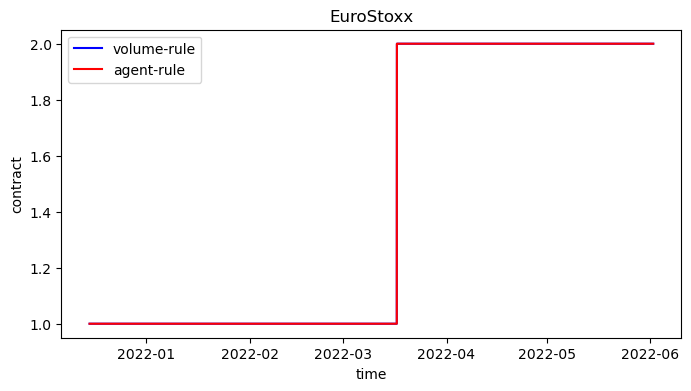

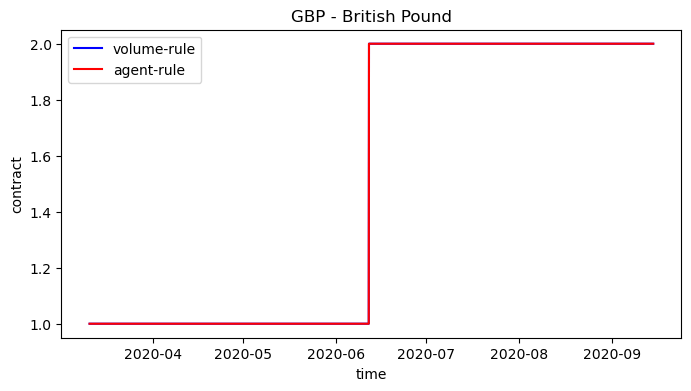

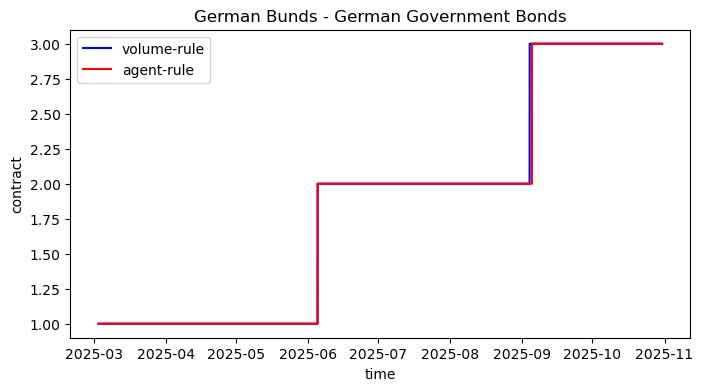

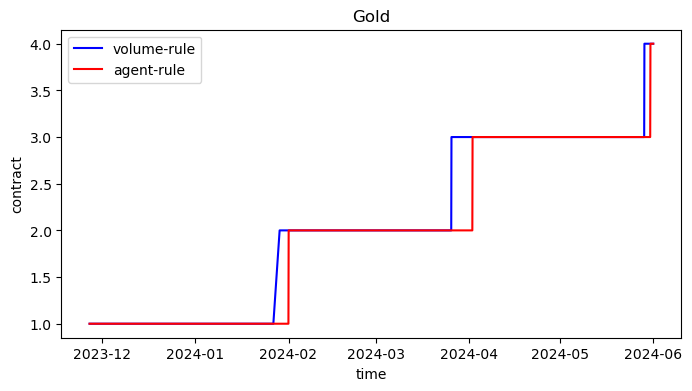

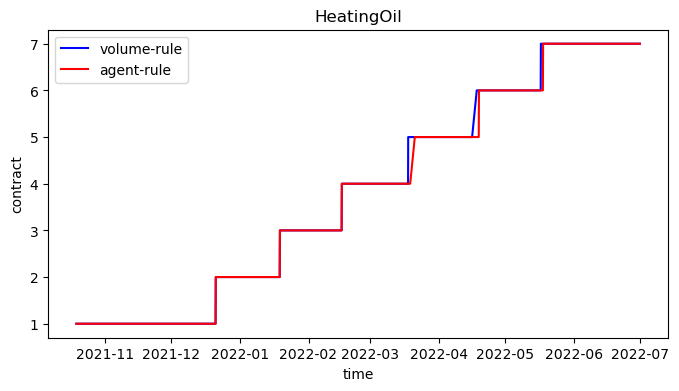

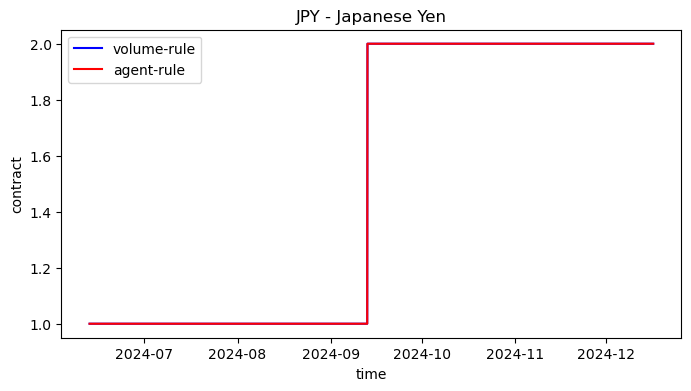

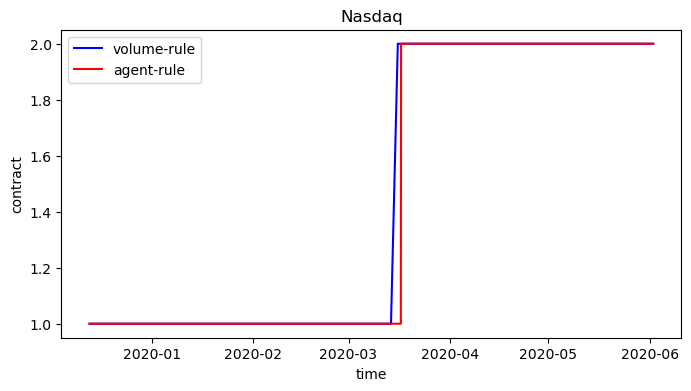

In [11]:
raw_data_path=RAW_DATA_DIR
volume_rule_path=DATA_DIR/'futures'/'minute_5'
agent_rule_path=DATA_DIR/'futures_right'/'minute_5'

markets=sorted([p.name for p in raw_data_path.iterdir() if p.is_dir()])

for market in markets:
    market_path=raw_data_path/market
        
    # volume_rule
    vr_df=pd.read_parquet(volume_rule_path/f'{market}.parquet').reset_index(drop=True)
    # agent_rule
    ar_prep=pd.read_parquet(agent_rule_path/f'{market}_prep.parquet').reset_index(drop=True)
    ar_trading=pd.read_parquet(agent_rule_path/f'{market}.parquet').reset_index(drop=True)
    ar_df=pd.concat([ar_prep,ar_trading],axis=0).drop_duplicates('time',keep='last').sort_values('time').reset_index(drop=True)
    
    # compare
    compare_df=vr_df[['time','contract']].merge(ar_df[['time','rank']],on='time',how='outer')
    compare_df['contract']=(compare_df['contract']+1).ffill()
    compare_df['rank']=compare_df['rank'].ffill()
    
    plt.figure(figsize=(8,4))
    plt.plot(compare_df['time'],compare_df['contract'],color='blue',label='volume-rule')
    plt.plot(compare_df['time'],compare_df['rank'],color='red',label='agent-rule')
    plt.legend()
    plt.xlabel('time')
    plt.ylabel('contract')
    plt.title(f'{market}')
    plt.show()
    

After fixing the problem, the plot comes back to normal.

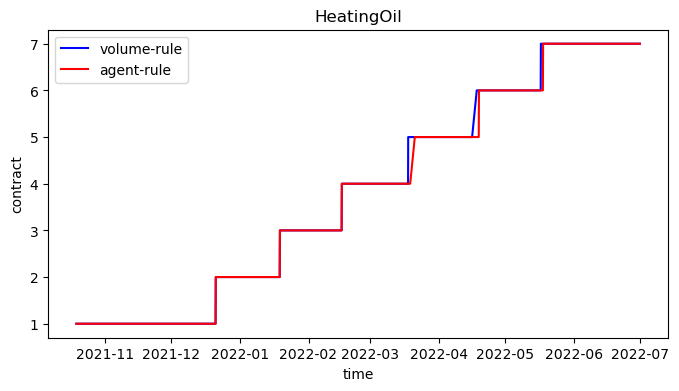

In [12]:
raw_data_path=RAW_DATA_DIR
volume_rule_path=DATA_DIR/'futures'/'minute_5'
agent_rule_path=DATA_DIR/'futures_right'/'minute_5'

market='HeatingOil'
market_path=raw_data_path/market
    
# volume_rule
vr_df=pd.read_parquet(volume_rule_path/f'{market}.parquet').reset_index(drop=True)
# agent_rule
ar_prep=pd.read_parquet(agent_rule_path/f'{market}_prep.parquet').reset_index(drop=True)
ar_trading=pd.read_parquet(agent_rule_path/f'{market}.parquet').reset_index(drop=True)
ar_df=pd.concat([ar_prep,ar_trading],axis=0).drop_duplicates('time',keep='last').sort_values('time').reset_index(drop=True)

# compare
compare_df=vr_df[['time','contract']].merge(ar_df[['time','rank']],on='time',how='outer')
compare_df['contract']=(compare_df['contract']+1).ffill()
compare_df['rank']=compare_df['rank'].ffill()

plt.figure(figsize=(8,4))
plt.plot(compare_df['time'],compare_df['contract'],color='blue',label='volume-rule')
plt.plot(compare_df['time'],compare_df['rank'],color='red',label='agent-rule')
plt.legend()
plt.xlabel('time')
plt.ylabel('contract')
plt.title(f'{market}')
plt.show()


# **Run the following code cells to clean data and save cleaned data to the project folder**

## **Volume-rule**

In [13]:
# 1. clean futures data: 1-minute

def clean_futures_data(
    raw_data_path: Path,
    output_path:Path
)->None:

    markets=sorted([p.name for p in raw_data_path.iterdir() if p.is_dir()])

    fields=['open', 'high', 'low', 'close', 'volume']


    for market in markets:
        market_path=raw_data_path/market
        files=sorted([p.name for p in market_path.glob("*.csv")
                    if not p.name.startswith("AIAgent")])
        print(f'{market}: {files}')
        hour_adjust=6
        
        volume_series_list=[]
        data_dict={c: [] for c in fields}
        contract_names=[f[:-4] for f in files]
        
        for file in files:
            data=pd.read_csv(RAW_DATA_DIR/market/file,header=None)
            data=data.dropna() # delete rows with missing value
            data.columns=['time','open','high','low','close','volume']
            data=data.sort_values('time')
            data[['open','high','low','close','volume']]=data[['open','high','low','close','volume']].astype(float)
            data['time']=pd.to_datetime(data['time'])+pd.Timedelta(hours=hour_adjust) # change from calendar days to trading days
            data['date']=data['time'].dt.date
            data.set_index('time',inplace=True)
            
            # delete low volume period (beginning period)
            daily_volume=data.groupby('date')['volume'].sum()
            daily_volume_norm=daily_volume/daily_volume.max()
            valid_dates=daily_volume_norm[daily_volume_norm>0.1]
            if len(valid_dates)==0:
                print(f'Warning: {market}, {file}, no valid dates')
                continue
            start_date=pd.Timestamp(valid_dates.index[0])
            data=data.loc[data.index>=start_date]
            
            for c in fields:
                series=data[c].copy()
                series.name=file[:-4]
                data_dict[c].append(series)
            
            daily_volume=data.groupby('date')['volume'].sum()
            daily_volume.name=file[:-4]
            volume_series_list.append(daily_volume)
            
        if len(volume_series_list)==0:
            print(f'Warning: {market}, daily volume series list is empty.')
            continue
        
        # decide the rolling
        volume_df=pd.concat(volume_series_list,axis=1,join='outer').sort_index()
        volume_df=volume_df.reindex(contract_names,axis=1)
        volume_df=volume_df.dropna(how='all')
        volume_df['contract']=np.nanargmax(volume_df.values,axis=1)
        volume_df.reset_index(inplace=True)

        for c in fields:
            df=pd.concat(data_dict[c],axis=1,join='outer')
            df=df.reset_index()
            df['date']=df['time'].dt.date
            df=df.merge(volume_df[['date','contract']],on='date',how='inner')
            df=df.set_index('time')
            
            values = df[contract_names].to_numpy()
            row_idx = np.arange(len(df))
            col_idx = df['contract'].to_numpy()
            df[c] = values[row_idx, col_idx]
            data_dict[c] = df[c]
            
        combined_df=pd.DataFrame.from_dict(data_dict)
        combined_df.reset_index(inplace=True)
        combined_df['date']=combined_df['time'].dt.date
        combined_df=combined_df.merge(volume_df[['date','contract']],on='date',how='inner')
        
        combined_df.to_parquet(output_path/f'{market}.parquet')

raw_data_path=RAW_DATA_DIR
output_path=DATA_DIR/'futures'/'minute_1'
output_path.mkdir(parents=True,exist_ok=True)
clean_futures_data(raw_data_path,output_path)

EuroStoxx: ['VGH22.csv', 'VGM22.csv']
GBP - British Pound: ['BPM20.csv', 'BPU20.csv']
German Bunds - German Government Bonds: ['RXM25.csv', 'RXU25.csv', 'RXZ25.csv']
Gold: ['GCG24.csv', 'GCJ24.csv', 'GCM24.csv', 'GCQ24.csv']
HeatingOil: ['HOF22.csv', 'HOG22.csv', 'HOH22.csv', 'HOJ22.csv', 'HOK22.csv', 'HOM22.csv', 'HON22.csv']
JPY - Japanese Yen: ['JYU24.csv', 'JYZ24.csv']
Nasdaq: ['NQH20.csv', 'NQM20.csv', 'NQU20.csv']


In [14]:
# 2. trading dates

def get_trading_time(output_path:Path)->None:
    
    output_path.mkdir(parents=True,exist_ok=True)
    
    import yfinance as yf
    
    spx = yf.download(
        "^SPX",
        start="2016-01-01",
        auto_adjust=True,
        progress=False,
        group_by="column",
        threads=True
    )

    spx.columns = spx.columns.get_level_values(0)
    spx = spx[['Close']].rename(columns={'Close': 'spx'})
    spx.reset_index(inplace=True)
    spx.columns.name=None
    spx.columns=['date','spx']
    spx['date']=pd.to_datetime(spx['date'])
    
    spx.to_parquet(output_path/'SPX.parquet')
    
    
output_path=DATA_DIR/'trading'
get_trading_time(output_path)

In [15]:
# 3. clean AI agent data, also intergrate the ending dates

def clean_agent_data(
    raw_data_path: Path,
    futures_data_path:Path,
    trading_dates_path:Path,
    output_path:Path
)->None:
    
    markets=sorted([p.name for p in raw_data_path.iterdir() if p.is_dir()])

    for market in markets:
        print(f'========== {market} ==========')
        market_path=RAW_DATA_DIR/market
        ai_file=[p.name for p in market_path.glob("*.csv")
                if p.name.startswith("AIAgent")][0]
        hour_adjust=6
        
        ai_data=pd.read_csv(RAW_DATA_DIR/market/ai_file,header=None)
        ai_data.columns=['date','hour','minute','price','position']
        ai_data['date']=pd.to_datetime(ai_data['date'], unit='D', origin='1899-12-30')
        ai_data['time'] = (ai_data['date']
                        + pd.to_timedelta(ai_data['hour'], unit='h') 
                        + pd.to_timedelta(ai_data['minute'], unit='m'))
        ai_data['time']=ai_data['time']+pd.Timedelta(hours=hour_adjust)
        ai_data['date']=pd.to_datetime(ai_data['time'].dt.date)
        ai_data['hour']=(ai_data['time'].dt.hour).astype(int)
        ai_data['minute']=(ai_data['time'].dt.minute).astype(int)
        ai_data=ai_data.sort_values('time')
        
        ai_data['weekdays']=ai_data['date'].dt.day_name()
        if len(ai_data[ai_data['weekdays']=='Sunday'])>0:
            print('include weekends')
        ai_data=ai_data[ai_data['weekdays']!='Sunday']
        ai_data=ai_data.drop('weekdays',axis=1)
        
        # intergrate ending date
        futures_data=pd.read_parquet(futures_data_path/f'{market}.parquet')
        futures_data['date']=pd.to_datetime(futures_data['date'])
        end_date=min(futures_data['date'].iloc[-1],ai_data['date'].iloc[-1])
        futures_data=futures_data[futures_data['date']<=end_date]
        ai_data=ai_data[ai_data['date']<=end_date]
        
        futures_data.to_parquet(futures_data_path/f'{market}.parquet')
        ai_data.to_parquet(output_path/f'{market}.parquet')
        

raw_data_path=RAW_DATA_DIR
futures_data_path=DATA_DIR/'futures'/'minute_1'
trading_dates_path=DATA_DIR/'trading'
output_path=DATA_DIR/'agent'
clean_agent_data(raw_data_path,futures_data_path,trading_dates_path,output_path)

========== EuroStoxx ==========
========== GBP - British Pound ==========
========== German Bunds - German Government Bonds ==========
========== Gold ==========
========== HeatingOil ==========
========== JPY - Japanese Yen ==========
========== Nasdaq ==========


In [16]:
# 4. resample futures data

def resample_data(
    data_path:Path,
    output_path:Path,
    minutes:int,
)->None:
    
    output_path=output_path/f'minute_{minutes}'
    output_path.mkdir(parents=True,exist_ok=True)
    
    files=sorted([p.name for p in data_path.glob("*.parquet")])
    markets=[f[:-8] for f in files]
    
    for market in markets:
        print(f'========== {market} ==========')
        
        data=pd.read_parquet(data_path/f'{market}.parquet')
        data.set_index('time',inplace=True)
        
        data['ones']=1
        data=data.resample(f'{minutes}min',label='right',closed='left').agg({
            'open':'first',
            'high':'max',
            'low':'min',
            'close':'last',
            'volume':'sum',
            'date':'first',
            'contract':'first',
            'ones': 'sum'
            }).rename(columns={'ones': 'n_rows'}).dropna(subset=['open', 'high', 'low', 'close']).reset_index()
        
        data['contract']=data['contract'].astype(int)
        data['n_rows']=data['n_rows']/float(minutes)
        
        data.to_parquet(output_path/f'{market}.parquet')

  
data_path=DATA_DIR/'futures'/'minute_1'
output_path=DATA_DIR/'futures'
minutes=5
resample_data(data_path,output_path,minutes)

========== EuroStoxx ==========
========== GBP - British Pound ==========
========== German Bunds - German Government Bonds ==========
========== Gold ==========
========== HeatingOil ==========
========== JPY - Japanese Yen ==========
========== Nasdaq ==========


## **Agent-rule**

In [17]:
def parse_contract_maturity(contract_name: str) -> pd.Timestamp:
    contract_name = str(contract_name).upper()
    m = re.search(r'([FGHJKMNQUVXZ])(\d{2})$', contract_name)
    if m is None:
        raise ValueError(f"Cannot parse maturity from contract name: {contract_name}")
    
    month = MONTH_CODE[m.group(1)]
    year = 2000 + int(m.group(2))
    return pd.Timestamp(year=year, month=month, day=1)


def build_contract_rank_map(futures_dict: dict) -> dict:
    contract_names = list(futures_dict.keys())
    maturity_pairs = [(name, parse_contract_maturity(name)) for name in contract_names]
    maturity_pairs = sorted(maturity_pairs, key=lambda x: x[1])
    
    rank_map = {name: i + 1 for i, (name, _) in enumerate(maturity_pairs)}
    return rank_map


def resample_one_contract_to_5min(
    df: pd.DataFrame, 
    time_col: str = "time",
) -> pd.DataFrame:
    """
    Resample one contract's 1-minute dataframe to 5-minute left-inclusive bars.
    """
    x = df.copy()
    x[time_col] = pd.to_datetime(x[time_col])
    x = x.sort_values(time_col).set_index(time_col)

    out = x.resample(
        "5min",
        label="right",
        closed="left"
    ).agg({
        "open": "first",
        "high": "max",
        "low": "min",
        "close": "last",
        "volume": "sum"
    })

    out = out.dropna(subset=["close"]).reset_index()
    return out


def resample_all_contracts(futures_dict: dict) -> dict:
    futures_5m_dict = {}
    for contract_name, df in futures_dict.items():
        futures_5m_dict[contract_name] = resample_one_contract_to_5min(df)
    return futures_5m_dict


def identify_agent_contracts(
    agent_df: pd.DataFrame,
    futures_dict: dict,
    price_tol: float = 0.0,
    time_col: str = "time",
    agent_price_col: str = "price"
) -> pd.DataFrame:

    agent = agent_df.copy()
    agent[time_col] = pd.to_datetime(agent[time_col])
    agent = agent.sort_values(time_col).reset_index(drop=True)

    # build rank map
    rank_map = build_contract_rank_map(futures_dict)

    # resample all contracts to 5min
    futures_5m_dict = resample_all_contracts(futures_dict)
    
    # same last timestamp of agent & futures data
    last_agent_timestamp = agent[time_col].max()
    last_futures_timestamp = max(
        df_5m[time_col].max()
        for df_5m in futures_5m_dict.values()
        if len(df_5m) > 0
    )
    last_timestamp = min(last_agent_timestamp, last_futures_timestamp)
    agent = agent[agent[time_col] <= last_timestamp].copy()

    # build quick lookup for each contract:
    lookup_dict = {}
    for contract_name, df_5m in futures_5m_dict.items():
        temp = df_5m.copy()
        temp = temp[temp[time_col] <= last_timestamp]
        temp = temp.set_index(time_col)[["close", "volume"]]
        lookup_dict[contract_name] = temp
        
    # to store result row by row
    matched_contracts_all = []
    matched_ranks_all = []
    matched_volumes_all = []
    match_status_all=[]

    # first iterate: agent
    for _, row in agent.iterrows():
        t = row[time_col]
        p = row[agent_price_col]

        matched_contracts = []
        matched_ranks = []
        matched_volumes = []
        time_found = False

        # second iterate: future contracts
        for contract_name, lookup_df in lookup_dict.items():
            if t not in lookup_df.index:
                continue
            
            time_found = True

            close_price = lookup_df.at[t, "close"]
            vol = lookup_df.at[t, "volume"]

            if price_tol == 0.0:
                is_match = (p == close_price)
            else:
                is_match = abs(p - close_price) <= price_tol

            if is_match:
                matched_contracts.append(contract_name)
                matched_ranks.append(rank_map[contract_name])
                matched_volumes.append(vol)
                
        if len(matched_contracts) > 0:
            match_status_all.append("done")
        elif not time_found:
            match_status_all.append("time_not_found")
        else:
            match_status_all.append("no_price")

        matched_contracts_all.append(matched_contracts)
        matched_ranks_all.append(matched_ranks)
        matched_volumes_all.append(matched_volumes)

    agent["matched_contracts"] = matched_contracts_all
    agent["matched_contract_ranks"] = matched_ranks_all
    agent["matched_contract_volumes"] = matched_volumes_all
    agent["match_status"] = match_status_all

    # choose one by largest volume if multiple contracts match
    chosen_contract = []
    chosen_rank = []
    chosen_volume = []

    for contracts, ranks, vols in zip(
        agent["matched_contracts"],
        agent["matched_contract_ranks"],
        agent["matched_contract_volumes"]
    ):
        if len(contracts) == 0:
            chosen_contract.append(np.nan)
            chosen_rank.append(np.nan)
            chosen_volume.append(np.nan)
        elif len(contracts) == 1:
            chosen_contract.append(contracts[0])
            chosen_rank.append(ranks[0])
            chosen_volume.append(vols[0])
        else:
            idx = int(np.argmax(vols))
            chosen_contract.append(contracts[idx])
            chosen_rank.append(ranks[idx])
            chosen_volume.append(vols[idx])

    agent["chosen_contract"] = chosen_contract
    agent["chosen_contract_rank"] = chosen_rank
    agent["chosen_contract_volume"] = chosen_volume

    return agent


def build_front_5min_from_agent(
    agent: pd.DataFrame,
    futures_dict: dict,
    time_col: str = "time",
    agent_price_col: str = "price"
) -> pd.DataFrame:

    futures_5m_dict = resample_all_contracts(futures_dict)

    lookup_5m = {}
    for contract, df in futures_5m_dict.items():
        temp = df.copy()
        temp[time_col] = pd.to_datetime(temp[time_col])
        temp = temp.set_index(time_col)
        lookup_5m[contract] = temp

    rows = []

    for _, row in agent.iterrows():
        t = row[time_col]
        p_agent = row[agent_price_col]
        contract = row["front_contract"]
        status = row["match_status"]

        out = {
            time_col: t,
            "contract": contract,
            "rank": row["front_rank"],
            "match_status": status,
        }

        if contract in lookup_5m and t in lookup_5m[contract].index:
            bar = lookup_5m[contract].loc[t]

            if status == "done":
                out.update({
                    "open": bar["open"],
                    "high": bar["high"],
                    "low": bar["low"],
                    "close": bar["close"],
                    "volume": bar["volume"],
                })
            else:
                out.update({
                    "open": np.nan,
                    "high": np.nan,
                    "low": np.nan,
                    "close": p_agent,
                    "volume": np.nan,
                })
        else:
            out.update({
                "open": np.nan,
                "high": np.nan,
                "low": np.nan,
                "close": p_agent,
                "volume": np.nan,
            })

        rows.append(out)

    return pd.DataFrame(rows)


def build_front_1min_from_agent(
    agent: pd.DataFrame,
    futures_dict: dict,
    time_col: str = "time",
    agent_price_col: str = "price"
) -> pd.DataFrame:

    lookup_1m = {}

    for contract, df in futures_dict.items():
        temp = df.copy()
        temp[time_col] = pd.to_datetime(temp[time_col])
        temp = temp.sort_values(time_col).set_index(time_col)
        lookup_1m[contract] = temp

    rows = []

    for _, row in agent.iterrows():
        t = row[time_col]
        p_agent = row[agent_price_col]
        contract = row["front_contract"]
        status = row["match_status"]

        interval_times = pd.date_range(
            start=t - pd.Timedelta(minutes=5),
            end=t - pd.Timedelta(minutes=1),
            freq="1min"
        )

        if status == "done" and contract in lookup_1m:
            contract_1m = lookup_1m[contract]
            bars = contract_1m.reindex(interval_times).reset_index()
            bars = bars.rename(columns={"index": time_col})

            bars["contract"] = contract
            bars["rank"] = row["front_rank"]
            bars["agent_time"] = t
            bars["match_status"] = status

        else:
            bars = pd.DataFrame({
                time_col: interval_times,
                "open": np.nan,
                "high": np.nan,
                "low": np.nan,
                "close": np.nan,
                "volume": np.nan,
                "contract": contract,
                "rank": row["front_rank"],
                "agent_time": t,
                "match_status": status,
            })

            # last 1-min bar close equals agent price
            bars.loc[bars[time_col] == t - pd.Timedelta(minutes=1), "close"] = p_agent

        rows.append(bars)

    return pd.concat(rows, ignore_index=True)


def build_prep_5min_from_agent(
    agent: pd.DataFrame,
    futures_dict: dict,
    time_col: str = "time",
) -> pd.DataFrame:
    if agent.empty:
        return pd.DataFrame(
            columns=[time_col, "open", "high", "low", "close", "volume", "contract", "rank"]
        )

    first_agent_timestamp, first_front_contract, first_front_rank, prep_start_date = (
        get_prep_window_info(agent, futures_dict, time_col=time_col)
    )

    contract_5m = resample_one_contract_to_5min(
        futures_dict[first_front_contract], time_col=time_col
    )
    prep = contract_5m[
        (contract_5m[time_col] < first_agent_timestamp)
        & (contract_5m[time_col].dt.normalize() >= prep_start_date)
    ].copy()
    prep["contract"] = first_front_contract
    prep["rank"] = first_front_rank

    return prep[[time_col, "open", "high", "low", "close", "volume", "contract", "rank"]]


def build_prep_1min_from_agent(
    agent: pd.DataFrame,
    futures_dict: dict,
    time_col: str = "time",
) -> pd.DataFrame:
    if agent.empty:
        return pd.DataFrame(
            columns=[time_col, "open", "high", "low", "close", "volume", "contract", "rank"]
        )

    first_agent_timestamp, first_front_contract, first_front_rank, prep_start_date = (
        get_prep_window_info(agent, futures_dict, time_col=time_col)
    )

    prep = futures_dict[first_front_contract].copy()
    prep[time_col] = pd.to_datetime(prep[time_col])
    prep = prep.sort_values(time_col)
    prep = prep[
        (prep[time_col] < first_agent_timestamp)
        & (prep[time_col].dt.normalize() >= prep_start_date)
    ].copy()
    prep["contract"] = first_front_contract
    prep["rank"] = first_front_rank

    return prep[[time_col, "open", "high", "low", "close", "volume", "contract", "rank"]]


def get_prep_window_info(
    agent: pd.DataFrame,
    futures_dict: dict,
    time_col: str = "time",
):
    agent_sorted = agent.sort_values(time_col)
    first_agent_timestamp = pd.to_datetime(agent_sorted[time_col]).min()
    first_front_contract = agent_sorted["front_contract"].iloc[0]
    first_front_rank = int(agent_sorted["front_rank"].iloc[0])

    contract_df = futures_dict[first_front_contract].copy()
    contract_df[time_col] = pd.to_datetime(contract_df[time_col])
    contract_df = contract_df.sort_values(time_col)
    contract_df["trade_date"] = contract_df[time_col].dt.normalize()

    daily_volume = contract_df.groupby("trade_date", as_index=False)["volume"].sum()
    volume_threshold = daily_volume["volume"].max() / 10.0
    liquid_days = daily_volume[daily_volume["volume"] >= volume_threshold]

    if liquid_days.empty:
        prep_start_date = contract_df["trade_date"].min()
    else:
        prep_start_date = liquid_days["trade_date"].iloc[0]

    return first_agent_timestamp, first_front_contract, first_front_rank, prep_start_date

In [18]:
def save_data(
    raw_data_path:Path=RAW_DATA_DIR,
    agent_output_path:Path=DATA_DIR/'agent_right',
    futures_output_path:Path=DATA_DIR/'futures_right',
):
    
    agent_output_path.mkdir(parents=True,exist_ok=True)
    futures_1min=futures_output_path/'minute_1'
    futures_5min=futures_output_path/'minute_5'
    futures_1min.mkdir(parents=True,exist_ok=True)
    futures_5min.mkdir(parents=True,exist_ok=True)


    markets=sorted([p.name for p in raw_data_path.iterdir() if p.is_dir()])
    for market in markets:
        print(f'======== {market} ========')
        market_path=raw_data_path/market
        
        # files
        files=sorted([p.name for p in market_path.glob("*.csv")
                    if not p.name.startswith("AIAgent")])
        ai_file=[p.name for p in market_path.glob("*.csv")
                    if p.name.startswith("AIAgent")][0]

        # futures_data
        futures_dict=dict()
        for f in files:
            data=pd.read_csv(RAW_DATA_DIR/market/f,header=None)
            data=data.dropna() # delete rows with missing value, this doesn't change the results here
            data.columns=['time','open','high','low','close','volume']
            data['time']=pd.to_datetime(data['time'])+ pd.Timedelta(hours=6) # change to trading clock
            data = data[data["time"].dt.dayofweek < 5]                    # delete Saturdays and Sundays
            data['hour']=(data['time'].dt.hour).astype(int)
            data=data[data['hour']!=23]                                   # delete breaking time
            data=data[['time','open','high','low','close','volume']]
            futures_dict[f[:-4]]=data
        
        # agent_data
        agent_df=pd.read_csv(RAW_DATA_DIR/market/ai_file,header=None)
        agent_df.columns=['date','hour','minute','price','position']
        agent_df['date']=pd.to_datetime(agent_df['date'], unit='D', origin='1899-12-30')
        agent_df['time'] = (agent_df['date']
                            + pd.to_timedelta(agent_df['hour'], unit='h') 
                            + pd.to_timedelta(agent_df['minute'], unit='m'))
        agent_df['time']=pd.to_datetime(agent_df['time']) + pd.Timedelta(hours=6) # change to trading clock
        agent_df = agent_df[agent_df["time"].dt.dayofweek < 5]                    # delete Saturdays and Sundays
        agent_df['hour']=(agent_df['time'].dt.hour).astype(int)
        # delete breaking time
        agent_df = agent_df[
            ~(
                ((agent_df["time"].dt.hour == 23) & (agent_df["time"].dt.minute >= 5))
                | ((agent_df["time"].dt.hour == 0) & (agent_df["time"].dt.minute == 0))
            )
        ] 
        
        # result
        agent=identify_agent_contracts(agent_df,futures_dict)
        agent["front_rank"] = agent["chosen_contract_rank"].ffill()
        agent["front_rank"] = agent["front_rank"].fillna(1.0).astype(int)
        rank_to_contract = {
            rank: contract
            for contract, rank in build_contract_rank_map(futures_dict).items()
        }
        agent["front_contract"] = agent["front_rank"].map(rank_to_contract)

        front_5m = build_front_5min_from_agent(agent, futures_dict)
        front_1m = build_front_1min_from_agent(agent, futures_dict)
        prep_5m = build_prep_5min_from_agent(agent, futures_dict)
        prep_1m = build_prep_1min_from_agent(agent, futures_dict)
        
        front_5m=front_5m.reset_index(drop=True)
        front_1m=front_1m.reset_index(drop=True)
        prep_5m=prep_5m.reset_index(drop=True)
        prep_1m=prep_1m.reset_index(drop=True)
        agent=agent.reset_index(drop=True)
        
        front_5m.to_parquet(futures_5min/f'{market}.parquet')
        front_1m.to_parquet(futures_1min/f'{market}.parquet')
        prep_5m.to_parquet(futures_5min / f"{market}_prep.parquet")
        prep_1m.to_parquet(futures_1min / f"{market}_prep.parquet")
        agent.to_parquet(agent_output_path/f'{market}.parquet')


    
raw_data_path=RAW_DATA_DIR
agent_output_path=DATA_DIR/'agent_right'
futures_output_path=DATA_DIR/'futures_right'
save_data(raw_data_path, agent_output_path, futures_output_path)

======== EuroStoxx ========
======== GBP - British Pound ========
======== German Bunds - German Government Bonds ========
======== Gold ========
======== HeatingOil ========
======== JPY - Japanese Yen ========
======== Nasdaq ========


In [19]:
# solve the problem of HeatingOil

def fix_heatingoil(
    raw_path:Path,
    vr_path:Path,
    ar_path:Path,
):
    
    market='HeatingOil'
    
    vr_1=pd.read_parquet(vr_path/'minute_1'/f'{market}.parquet')
    vr_5=pd.read_parquet(vr_path/'minute_5'/f'{market}.parquet')
    ar_trading_1=pd.read_parquet(ar_path/'minute_1'/f'{market}.parquet')
    ar_trading_5=pd.read_parquet(ar_path/'minute_5'/f'{market}.parquet')
    ar_prep_1=pd.read_parquet(ar_path/'minute_1'/f'{market}_prep.parquet')
    ar_prep_5=pd.read_parquet(ar_path/'minute_5'/f'{market}_prep.parquet')
    
    # change trading
    ar_trading_1['rank']=ar_trading_1['rank'].replace(1,4)
    ar_trading_5['rank']=ar_trading_5['rank'].replace(1,4)
    # chanege prep
    # 1.
    ar_prep_1=vr_1[vr_1['time']<ar_trading_1['time'].iloc[0]]
    ar_prep_5=vr_5[vr_5['time']<ar_trading_5['time'].iloc[0]]
    # 2.
    ar_prep_1=ar_prep_1.drop('date',axis=1)
    ar_prep_5=ar_prep_5.drop(['date','n_rows'],axis=1)
    # 3.
    ar_prep_1=ar_prep_1.rename(columns={'contract':'rank'})
    ar_prep_5=ar_prep_5.rename(columns={'contract':'rank'})
    # 4.
    market_path=raw_path/market
    files=sorted([p.name for p in market_path.glob("*.csv")
                if not p.name.startswith("AIAgent")])
    files=[f[:-4] for f in files]
    rank_to_contract = dict(enumerate(files))
    ar_prep_1['contract']=ar_prep_1['rank'].map(rank_to_contract)
    ar_prep_1['rank']=ar_prep_1['rank']+1
    ar_prep_5['contract']=ar_prep_5['rank'].map(rank_to_contract)
    ar_prep_5['rank']=ar_prep_5['rank']+1
    # 5.
    column_seq=['time','open','high','low','close','volume','contract','rank']
    ar_prep_1=ar_prep_1[column_seq]
    ar_prep_5=ar_prep_5[column_seq]
    
    ar_prep_1.to_parquet(ar_path/'minute_1'/f'{market}_prep.parquet')
    ar_prep_5.to_parquet(ar_path/'minute_5'/f'{market}_prep.parquet')
    ar_trading_1.to_parquet(ar_path/'minute_1'/f'{market}.parquet')
    ar_trading_5.to_parquet(ar_path/'minute_5'/f'{market}.parquet')
    

raw_path=RAW_DATA_DIR
vr_path=DATA_DIR/'futures'
ar_path=DATA_DIR/'futures_right'
fix_heatingoil(raw_path,vr_path,ar_path)